# Held-out experiment comparison

Comparison of per-patient test metrics exported by notebook 04. Patient alignment, evaluation settings, and domain membership are checked before paired differences and uncertainty summaries are computed.

In [1]:
from pathlib import Path
import os
import sys
from functools import partial
from datetime import datetime

_start = Path(os.environ.get("BRATS_PROJECT_ROOT", Path.cwd())).expanduser().resolve()
PROJECT_ROOT = next(
    (p for p in (_start, *_start.parents) if (p / "src" / "brats_pipeline").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Place notebooks/ and src/ under one project root, or set BRATS_PROJECT_ROOT.")
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT)
from brats_pipeline.common import ProjectPaths
paths_io = ProjectPaths(PROJECT_ROOT)
resolve_existing_path = paths_io.resolve
print("Project:", PROJECT_ROOT)

Project: /home/mandrakedrink/projects/research_ts_bs


In [2]:
import os
import json
import math
import shutil
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from IPython.display import display, Markdown

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)

warnings.filterwarnings("default")

## TEST configuration

In [3]:
CFG = {
    # Project-level paths.
    "project_root_hint": str(PROJECT_ROOT),
    "manifest": "data/processed/manifest_4clients_seed42.csv",
    "analysis_split": "test",

    # Output directories.
    "output_root": "docs/06_experiment_comparison_test",
    "tables_subdir": "tables",
    "figures_subdir": "figures",
    "reports_subdir": "reports",
    "logs_subdir": "logs",

    # Strict mode:
    # True  -> required experiments must exist and schema/split errors stop execution.
    # False -> missing optional artifacts are recorded but not fatal.
    "strict_required": True,

    # Bootstrap settings for confidence intervals.
    "bootstrap_n": 5000,
    "bootstrap_alpha": 0.05,
    "bootstrap_seed": 42,

    # Failure-analysis settings.
    "small_et_threshold_vox": 1000,
    "tiny_et_threshold_vox": 250,
    "low_dice_threshold": 0.50,
    "large_ratio_threshold": 3.0,
    "small_ratio_threshold": 0.33,
    "top_k_worst_cases": 15,

    # Plot export.
    "save_png": True,
    "save_pdf": True,
    "dpi": 300,

    # Primary paired comparison.
    "primary_reference_key": "centralized_s32_cew",
    "primary_current_key": "fedavg_s32_cew",

    # Experiments.
    "experiments": [
        {
            "key": "centralized_s32_cew",
            "name": "Centralized SegResNet32 final CE-weighted — TEST",
            "short_name": "C-S32 CEw",
            "family": "centralized",
            "stage": "final_backbone_test",
            "enabled": True,
            "required": True,
            "metrics_path": "models/centralized_segresnet32_final/full_volume_inference_test/full_volume_test_metrics.csv",
            "eval_config_path": "models/centralized_segresnet32_final/full_volume_inference_test/full_volume_eval_config.json",
            "history_path_candidates": [
                "models/centralized_segresnet32_final/history.csv",
                "models/centralized_segresnet32_final/training_history.csv",
                "models/centralized_segresnet32_final/centralized_history.csv",
                "models/centralized_segresnet32_final/segresnet_final_history.csv",
            ],
        },
        {
            "key": "fedavg_s32_cew",
            "name": "FedAvg SegResNet32 final CE-weighted — TEST",
            "short_name": "FedAvg-S32 CEw",
            "family": "federated",
            "stage": "final_fedavg_test",
            "enabled": True,
            "required": True,
            "metrics_path": "models/federated_fedavg_segresnet32_final/full_volume_inference_test/full_volume_test_metrics.csv",
            "eval_config_path": "models/federated_fedavg_segresnet32_final/full_volume_inference_test/full_volume_eval_config.json",
            "train_config_path": "models/federated_fedavg_segresnet32_final/fedavg_final_config.json",
            "history_path_candidates": [
                "models/federated_fedavg_segresnet32_final/fedavg_history.csv",
                "models/federated_fedavg_segresnet32_final/history.csv",
            ],
        },
        {
            "key": "fedprox_s32_cew",
            "name": "FedProx SegResNet32 final CE-weighted — TEST",
            "short_name": "FedProx-S32 CEw",
            "family": "federated",
            "stage": "final_fedprox_test",
            "enabled": True,
            "required": True,
            "metrics_path": "models/federated_fedprox_segresnet32_final/full_volume_inference_test/full_volume_test_metrics.csv",
            "eval_config_path": "models/federated_fedprox_segresnet32_final/full_volume_inference_test/full_volume_eval_config.json",
            "train_config_path": "models/federated_fedprox_segresnet32_final/fedprox_final_config.json",
            "history_path_candidates": [
                "models/federated_fedprox_segresnet32_final/fedprox_history.csv",
                "models/federated_fedprox_segresnet32_final/history.csv",
            ],
        },
        {
            "key": "centralized_v2_s16",
            "name": "Centralized V2 SegResNet16 — TEST",
            "short_name": "C-S16 V2",
            "family": "centralized",
            "stage": "historical_baseline_test",
            "enabled": False,
            "required": False,
            "metrics_path": "models/centralized_baseline_v2/full_volume_inference_test/full_volume_test_metrics.csv",
            "eval_config_path": "models/centralized_baseline_v2/full_volume_inference_test/full_volume_eval_config.json",
            "history_path_candidates": [
                "models/centralized_baseline_v2/history.csv",
                "models/centralized_baseline_v2/training_history.csv",
                "models/centralized_baseline_v2/centralized_history.csv",
            ],
        },
    ],
}

CFG

{'project_root_hint': '/home/mandrakedrink/projects/research_ts_bs',
 'manifest': 'data/processed/manifest_4clients_seed42.csv',
 'analysis_split': 'test',
 'output_root': 'docs/06_experiment_comparison_test',
 'tables_subdir': 'tables',
 'figures_subdir': 'figures',
 'reports_subdir': 'reports',
 'logs_subdir': 'logs',
 'strict_required': True,
 'bootstrap_n': 5000,
 'bootstrap_alpha': 0.05,
 'bootstrap_seed': 42,
 'small_et_threshold_vox': 1000,
 'tiny_et_threshold_vox': 250,
 'low_dice_threshold': 0.5,
 'large_ratio_threshold': 3.0,
 'small_ratio_threshold': 0.33,
 'top_k_worst_cases': 15,
 'save_png': True,
 'save_pdf': True,
 'dpi': 300,
 'primary_reference_key': 'centralized_s32_cew',
 'primary_current_key': 'fedavg_s32_cew',
 'experiments': [{'key': 'centralized_s32_cew',
   'name': 'Centralized SegResNet32 final CE-weighted — TEST',
   'short_name': 'C-S32 CEw',
   'family': 'centralized',
   'stage': 'final_backbone_test',
   'enabled': True,
   'required': True,
   'metrics_p

In [4]:
# Enable the historical SegResNet16 entry in CFG when its test metrics are available.

CFG["experiments"]

[{'key': 'centralized_s32_cew',
  'name': 'Centralized SegResNet32 final CE-weighted — TEST',
  'short_name': 'C-S32 CEw',
  'family': 'centralized',
  'stage': 'final_backbone_test',
  'enabled': True,
  'required': True,
  'metrics_path': 'models/centralized_segresnet32_final/full_volume_inference_test/full_volume_test_metrics.csv',
  'eval_config_path': 'models/centralized_segresnet32_final/full_volume_inference_test/full_volume_eval_config.json',
  'history_path_candidates': ['models/centralized_segresnet32_final/history.csv',
   'models/centralized_segresnet32_final/training_history.csv',
   'models/centralized_segresnet32_final/centralized_history.csv',
   'models/centralized_segresnet32_final/segresnet_final_history.csv']},
 {'key': 'fedavg_s32_cew',
  'name': 'FedAvg SegResNet32 final CE-weighted — TEST',
  'short_name': 'FedAvg-S32 CEw',
  'family': 'federated',
  'stage': 'final_fedavg_test',
  'enabled': True,
  'required': True,
  'metrics_path': 'models/federated_fedavg_se

## Project root and output directories

In [5]:
OUTPUT_ROOT = PROJECT_ROOT / CFG["output_root"]
TABLE_DIR = OUTPUT_ROOT / CFG["tables_subdir"]
FIG_DIR = OUTPUT_ROOT / CFG["figures_subdir"]
REPORT_DIR = OUTPUT_ROOT / CFG["reports_subdir"]
LOG_DIR = OUTPUT_ROOT / CFG["logs_subdir"]

for d in [OUTPUT_ROOT, TABLE_DIR, FIG_DIR, REPORT_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("TABLE_DIR:", TABLE_DIR)
print("FIG_DIR:", FIG_DIR)
print("REPORT_DIR:", REPORT_DIR)
print("LOG_DIR:", LOG_DIR)

PROJECT_ROOT: /home/mandrakedrink/projects/research_ts_bs
OUTPUT_ROOT: /home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test
TABLE_DIR: /home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/tables
FIG_DIR: /home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/figures
REPORT_DIR: /home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/reports
LOG_DIR: /home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/logs


## Helper functions

In [6]:
def resolve_path(value):
    return paths_io.output(value)

existing_path_candidates = paths_io.candidates

first_existing_path = paths_io.first_existing


def read_json_if_exists(path_like):
    p = paths_io.resolve(path_like, required=False)
    if p is None:
        return None

    with open(p, "r", encoding="utf-8") as f:
        return json.load(f)


def save_dataframe(df, name, index=False, save_latex=True, save_markdown=True):
    """
    Save dataframe in CSV, Markdown, and LaTeX formats.
    """
    csv_path = TABLE_DIR / f"{name}.csv"
    df.to_csv(csv_path, index=index)

    outputs = {"csv": str(csv_path)}

    if save_markdown:
        md_path = TABLE_DIR / f"{name}.md"
        with open(md_path, "w", encoding="utf-8") as f:
            f.write(df.to_markdown(index=index))
            f.write("\n")
        outputs["markdown"] = str(md_path)

    if save_latex:
        tex_path = TABLE_DIR / f"{name}.tex"
        with open(tex_path, "w", encoding="utf-8") as f:
            try:
                f.write(df.to_latex(index=index, float_format="%.4f"))
            except Exception as exc:
                f.write(f"% Failed to export LaTeX: {exc}\n")
        outputs["latex"] = str(tex_path)

    return outputs


def save_figure(fig, name):
    """
    Save a matplotlib figure as PNG/PDF according to CFG.
    """
    outputs = {}
    if CFG.get("save_png", True):
        png_path = FIG_DIR / f"{name}.png"
        fig.savefig(png_path, dpi=CFG["dpi"], bbox_inches="tight")
        outputs["png"] = str(png_path)
    if CFG.get("save_pdf", True):
        pdf_path = FIG_DIR / f"{name}.pdf"
        fig.savefig(pdf_path, bbox_inches="tight")
        outputs["pdf"] = str(pdf_path)
    return outputs


def bootstrap_mean_ci(values, n_boot=None, alpha=None, seed=None):
    """
    Non-parametric bootstrap CI for the mean.
    Returns mean, lower CI, upper CI.
    """
    x = pd.Series(values).dropna().to_numpy(dtype=float)
    if len(x) == 0:
        return np.nan, np.nan, np.nan

    n_boot = int(CFG["bootstrap_n"] if n_boot is None else n_boot)
    alpha = float(CFG["bootstrap_alpha"] if alpha is None else alpha)
    seed = int(CFG["bootstrap_seed"] if seed is None else seed)

    rng = np.random.default_rng(seed)
    samples = rng.choice(x, size=(n_boot, len(x)), replace=True)
    boot_means = samples.mean(axis=1)

    lower = np.quantile(boot_means, alpha / 2)
    upper = np.quantile(boot_means, 1 - alpha / 2)
    return float(x.mean()), float(lower), float(upper)


def paired_wilcoxon_pvalue(delta_values):
    """
    Optional paired Wilcoxon signed-rank test for case-level deltas.
    Returns NaN if scipy is unavailable or test is invalid.
    """
    x = pd.Series(delta_values).dropna().to_numpy(dtype=float)
    x = x[np.abs(x) > 1e-12]
    if len(x) < 2:
        return np.nan
    try:
        from scipy.stats import wilcoxon
        return float(wilcoxon(x, alternative="two-sided").pvalue)
    except Exception:
        return np.nan


def safe_display(title, df, max_rows=30):
    display(Markdown(f"### {title}"))
    if len(df) > max_rows:
        display(df.head(max_rows))
        display(Markdown(f"Showing first {max_rows} of {len(df)} rows."))
    else:
        display(df)


def ensure_columns(df, required_columns, context):
    missing = [c for c in required_columns if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in {context}: {missing}")


def assert_or_warn(condition, message, strict=True):
    if condition:
        return
    if strict:
        raise AssertionError(message)
    warnings.warn(message)

In [7]:
import brats_pipeline.common as common

print(common.__file__)
print("first_existing exists:", hasattr(common.ProjectPaths, "first_existing"))

/home/mandrakedrink/projects/research_ts_bs/src/brats_pipeline/common.py
first_existing exists: True


## Load manifest and verify configured evaluation split

In [8]:
manifest_path = resolve_path(CFG["manifest"])
print("manifest_path:", manifest_path)

if not manifest_path.exists():
    raise FileNotFoundError(f"Manifest not found: {manifest_path}")

mf_df = pd.read_csv(manifest_path)
ensure_columns(mf_df, ["patient_id", "client_domain", "split"], "manifest")

split_domain_counts = (
    mf_df.groupby(["client_domain", "split"])
    .size()
    .rename("n")
    .reset_index()
    .sort_values(["client_domain", "split"])
)

eval_split = CFG.get("analysis_split", "test")
eval_manifest = mf_df[mf_df["split"] == eval_split].copy()
eval_domain_counts = (
    eval_manifest.groupby("client_domain")
    .size()
    .rename(f"n_{eval_split}")
    .reset_index()
    .sort_values("client_domain")
)

print("manifest shape:", mf_df.shape)
print(f"{eval_split} cases:", len(eval_manifest))
safe_display("Manifest split/domain counts", split_domain_counts)
safe_display(f"{eval_split.capitalize()} domain counts", eval_domain_counts)

save_dataframe(split_domain_counts, "00_manifest_split_domain_counts")
save_dataframe(eval_domain_counts, f"00_manifest_{eval_split}_domain_counts")

manifest_path: /home/mandrakedrink/projects/research_ts_bs/data/processed/manifest_4clients_seed42.csv
manifest shape: (1060, 4)
test cases: 211


### Manifest split/domain counts

,client_domain,split,n
0,TCGA-GBM,test,20
1,TCGA-GBM,train,72
2,TCGA-GBM,val,10
3,TCGA-LGG,test,13
4,TCGA-LGG,train,46
5,TCGA-LGG,val,6
6,UCSF-PDGM,test,76
7,UCSF-PDGM,train,268
8,UCSF-PDGM,val,38
9,UPENN-GBM,test,102


### Test domain counts

,client_domain,n_test
0,TCGA-GBM,20
1,TCGA-LGG,13
2,UCSF-PDGM,76
3,UPENN-GBM,102


{'csv': '/home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/tables/00_manifest_test_domain_counts.csv',
 'markdown': '/home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/tables/00_manifest_test_domain_counts.md',
 'latex': '/home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/tables/00_manifest_test_domain_counts.tex'}

## Build experiment registry

In [9]:
def resolve_project_artifact(path_like, required=True):
    """Resolve experiment artifacts relative to the project root only."""
    if path_like is None:
        return None

    p = Path(path_like)

    if not p.is_absolute():
        p = PROJECT_ROOT / p

    p = p.resolve()

    if required and not p.exists():
        raise FileNotFoundError(f"Project artifact not found: {p}")

    return p if p.exists() else None


def first_existing_project_artifact(path_candidates):
    """Return the first existing experiment artifact under PROJECT_ROOT."""
    if not path_candidates:
        return None

    for value in path_candidates:
        p = resolve_project_artifact(value, required=False)
        if p is not None:
            return p

    return None

In [10]:
registry_rows = []

for exp in CFG["experiments"]:
    row = dict(exp)

    # Metrics
    metrics_path = resolve_project_artifact(
        exp.get("metrics_path"),
        required=False,
    )

    row["metrics_path_abs"] = str(metrics_path) if metrics_path else None
    row["metrics_exists"] = metrics_path is not None

    row["metrics_checked_candidates"] = (
        " | ".join(
            str(PROJECT_ROOT / p)
            for p in existing_path_candidates(exp.get("metrics_path"))
        )
        if exp.get("metrics_path")
        else None
    )

    # Evaluation config
    eval_config_path = resolve_project_artifact(
        exp.get("eval_config_path"),
        required=False,
    )

    row["eval_config_path_abs"] = (
        str(eval_config_path) if eval_config_path else None
    )
    row["eval_config_exists"] = eval_config_path is not None

    # Training config
    train_config_path = resolve_project_artifact(
        exp.get("train_config_path"),
        required=False,
    )

    row["train_config_path_abs"] = (
        str(train_config_path) if train_config_path else None
    )
    row["train_config_exists"] = train_config_path is not None

    # Training history
    hist_path = first_existing_project_artifact(
        exp.get("history_path_candidates", [])
    )

    row["history_path_abs"] = str(hist_path) if hist_path else None
    row["history_exists"] = hist_path is not None

    registry_rows.append(row)


registry_df = pd.DataFrame(registry_rows)


# Required checks
for _, row in registry_df.iterrows():
    if bool(row["enabled"]) and bool(row["required"]):
        assert_or_warn(
            row["metrics_exists"],
            (
                f"Required metrics CSV missing for {row['name']}: "
                f"{row['metrics_path_abs']}\n"
                f"Checked candidates: {row.get('metrics_checked_candidates')}"
            ),
            strict=CFG["strict_required"],
        )


safe_display(
    "Experiment registry",
    registry_df[
        [
            "key",
            "name",
            "enabled",
            "required",
            "metrics_exists",
            "history_exists",
            "eval_config_exists",
            "train_config_exists",
            "metrics_path_abs",
            "history_path_abs",
            "metrics_checked_candidates",
        ]
    ],
)

save_dataframe(registry_df, "01_experiment_registry")

### Experiment registry

,key,name,enabled,required,metrics_exists,history_exists,eval_config_exists,train_config_exists,metrics_path_abs,history_path_abs,metrics_checked_candidates
0,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,True,True,True,True,True,False,/home/mandrakedrink/projects/research_ts_bs/mo...,/home/mandrakedrink/projects/research_ts_bs/mo...,/home/mandrakedrink/projects/research_ts_bs/mo...
1,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,True,True,True,True,True,True,/home/mandrakedrink/projects/research_ts_bs/mo...,/home/mandrakedrink/projects/research_ts_bs/mo...,/home/mandrakedrink/projects/research_ts_bs/mo...
2,fedprox_s32_cew,FedProx SegResNet32 final CE-weighted — TEST,True,True,True,False,True,False,/home/mandrakedrink/projects/research_ts_bs/mo...,None,/home/mandrakedrink/projects/research_ts_bs/mo...
3,centralized_v2_s16,Centralized V2 SegResNet16 — TEST,False,False,False,False,False,False,None,None,/home/mandrakedrink/projects/research_ts_bs/mo...


{'csv': '/home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/tables/01_experiment_registry.csv',
 'markdown': '/home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/tables/01_experiment_registry.md',
 'latex': '/home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/tables/01_experiment_registry.tex'}

## Load full-volume metrics

In [11]:
DICE_COLS = ["dice_WT", "dice_TC", "dice_ET"]
REGIONS = ["WT", "TC", "ET"]
GT_VOL_COLS = ["gt_WT_vox", "gt_TC_vox", "gt_ET_vox"]
PRED_VOL_COLS = ["pred_WT_vox", "pred_TC_vox", "pred_ET_vox"]
ABS_ERR_COLS = ["abs_WT_vox_error", "abs_TC_vox_error", "abs_ET_vox_error"]

REQUIRED_METRIC_COLUMNS = [
    "patient_id", "client_domain", "split",
    *DICE_COLS,
    *GT_VOL_COLS,
    *PRED_VOL_COLS,
    *ABS_ERR_COLS,
    "pred_to_gt_ET_ratio",
]


def load_metrics_for_experiment(exp_row):
    metrics_path = Path(exp_row["metrics_path_abs"])
    df = pd.read_csv(metrics_path)
    ensure_columns(df, REQUIRED_METRIC_COLUMNS, exp_row["name"])

    df = df.copy()

    expected_split = CFG.get("analysis_split")
    if expected_split is not None:
        observed_splits = sorted(df["split"].astype(str).unique())
        if observed_splits != [str(expected_split)]:
            raise ValueError(
                f"{exp_row['name']} metrics are not for split={expected_split!r}. "
                f"Observed splits: {observed_splits}. "
                "Run notebook 04 TEST and point metrics_path to full_volume_test_metrics.csv."
            )
    df["experiment_key"] = exp_row["key"]
    df["experiment_name"] = exp_row["name"]
    df["experiment_short_name"] = exp_row["short_name"]
    df["experiment_family"] = exp_row["family"]
    df["experiment_stage"] = exp_row["stage"]

    # Derived fields.
    df["dice_mean"] = df[DICE_COLS].mean(axis=1)
    df["gt_ET_present"] = df["gt_ET_vox"] > 0
    df["pred_ET_present"] = df["pred_ET_vox"] > 0
    df["et_false_positive"] = (df["gt_ET_vox"] == 0) & (df["pred_ET_vox"] > 0)
    df["et_false_negative_strict"] = (df["gt_ET_vox"] > 0) & (df["pred_ET_vox"] == 0)
    df["et_near_miss_low_pred"] = (df["gt_ET_vox"] > 0) & (df["pred_to_gt_ET_ratio"].fillna(np.inf) <= CFG["small_ratio_threshold"])
    df["et_overseg_ratio_flag"] = (df["gt_ET_vox"] > 0) & (df["pred_to_gt_ET_ratio"].fillna(0) >= CFG["large_ratio_threshold"])
    df["et_low_dice_flag"] = df["dice_ET"] < CFG["low_dice_threshold"]
    df["tc_low_dice_flag"] = df["dice_TC"] < CFG["low_dice_threshold"]
    df["wt_low_dice_flag"] = df["dice_WT"] < CFG["low_dice_threshold"]

    # Fixed ET volume bins for failure analysis.
    bins = [-1, 0, CFG["tiny_et_threshold_vox"], CFG["small_et_threshold_vox"], 5000, 20000, np.inf]
    labels = ["ET_absent", "ET_tiny", "ET_small", "ET_medium", "ET_large", "ET_very_large"]
    df["gt_ET_bin"] = pd.cut(df["gt_ET_vox"], bins=bins, labels=labels)

    return df

metrics_by_key = {}

for _, row in registry_df.iterrows():
    if not bool(row["enabled"]):
        continue
    if not bool(row["metrics_exists"]):
        print(f"Skipping missing non-required experiment: {row['key']} -> {row['metrics_path_abs']}")
        continue
    df = load_metrics_for_experiment(row)
    metrics_by_key[row["key"]] = df
    print(f"loaded {row['key']}: {df.shape} from {row['metrics_path_abs']}")

if len(metrics_by_key) == 0:
    raise RuntimeError("No experiment metrics loaded.")

all_metrics = pd.concat(metrics_by_key.values(), ignore_index=True)

safe_display("All loaded metric rows", all_metrics.head())
print("experiments loaded:", list(metrics_by_key.keys()))
print("all_metrics shape:", all_metrics.shape)

save_dataframe(all_metrics, "02_all_full_volume_metrics_long", index=False, save_latex=False)

loaded centralized_s32_cew: (211, 32) from /home/mandrakedrink/projects/research_ts_bs/models/centralized_segresnet32_final/full_volume_inference_test/full_volume_test_metrics.csv
loaded fedavg_s32_cew: (211, 32) from /home/mandrakedrink/projects/research_ts_bs/models/federated_fedavg_segresnet32_final/full_volume_inference_test/full_volume_test_metrics.csv
loaded fedprox_s32_cew: (211, 32) from /home/mandrakedrink/projects/research_ts_bs/models/federated_fedprox_segresnet32_final/full_volume_inference_test/full_volume_test_metrics.csv


### All loaded metric rows

,patient_id,client_domain,split,dice_WT,dice_TC,dice_ET,gt_WT_vox,gt_TC_vox,gt_ET_vox,pred_WT_vox,pred_TC_vox,pred_ET_vox,abs_WT_vox_error,abs_TC_vox_error,abs_ET_vox_error,pred_to_gt_ET_ratio,experiment_key,experiment_name,experiment_short_name,experiment_family,experiment_stage,dice_mean,gt_ET_present,pred_ET_present,et_false_positive,et_false_negative_strict,et_near_miss_low_pred,et_overseg_ratio_flag,et_low_dice_flag,tc_low_dice_flag,wt_low_dice_flag,gt_ET_bin
0,BraTS2021_00003,UCSF-PDGM,test,0.979194,0.977141,0.948207,99239,41466,24252,101428,42133,25349,2189,667,1097,1.045233,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,centralized,final_backbone_test,0.968181,True,True,False,False,False,False,False,False,False,ET_very_large
1,BraTS2021_00009,UCSF-PDGM,test,0.825370,0.932083,0.898392,27453,1865,1480,20099,1654,1256,7354,211,224,0.848649,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,centralized,final_backbone_test,0.885282,True,True,False,False,False,False,False,False,False,ET_medium
2,BraTS2021_00014,UCSF-PDGM,test,0.887734,0.582848,0.578966,38358,2559,2557,42040,6198,6048,3682,3639,3491,2.365272,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,centralized,final_backbone_test,0.683182,True,True,False,False,False,False,False,False,False,ET_medium
3,BraTS2021_00016,UCSF-PDGM,test,0.926408,0.941222,0.875090,74546,23300,12694,68417,25511,14942,6129,2211,2248,1.177092,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,centralized,final_backbone_test,0.914240,True,True,False,False,False,False,False,False,False,ET_large
4,BraTS2021_00019,UCSF-PDGM,test,0.858001,0.939845,0.922793,142997,11980,10375,188781,11792,10193,45784,188,182,0.982458,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,centralized,final_backbone_test,0.906880,True,True,False,False,False,False,False,False,False,ET_large


experiments loaded: ['centralized_s32_cew', 'fedavg_s32_cew', 'fedprox_s32_cew']
all_metrics shape: (633, 32)


{'csv': '/home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/tables/02_all_full_volume_metrics_long.csv',
 'markdown': '/home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/tables/02_all_full_volume_metrics_long.md'}

## Integrity checks

In [12]:
integrity_rows = []
expected_split = str(CFG.get("analysis_split", "test"))

for key, df in metrics_by_key.items():
    n_rows = len(df)
    n_unique_patients = df["patient_id"].nunique()
    n_duplicate_rows = n_rows - n_unique_patients
    observed_splits = sorted(df["split"].astype(str).unique())
    n_expected_split = int((df["split"].astype(str) == expected_split).sum())
    all_rows_are_expected_split = bool((df["split"].astype(str) == expected_split).all())

    dice_min = float(df[DICE_COLS].min().min())
    dice_max = float(df[DICE_COLS].max().max())
    min_volume = float(df[GT_VOL_COLS + PRED_VOL_COLS + ABS_ERR_COLS].min().min())

    integrity_rows.append({
        "experiment_key": key,
        "experiment_name": df["experiment_name"].iloc[0],
        "n_rows": n_rows,
        "n_unique_patients": n_unique_patients,
        "n_duplicate_rows": n_duplicate_rows,
        "expected_split": expected_split,
        "observed_splits": ", ".join(observed_splits),
        f"n_{expected_split}_rows": n_expected_split,
        "all_rows_are_expected_split": all_rows_are_expected_split,
        "dice_min": dice_min,
        "dice_max": dice_max,
        "min_volume_or_error": min_volume,
        "n_domains": df["client_domain"].nunique(),
        "domains": ", ".join(sorted(df["client_domain"].astype(str).unique())),
    })

    assert_or_warn(n_duplicate_rows == 0, f"Duplicate patient rows in {key}", CFG["strict_required"])
    assert_or_warn(
        all_rows_are_expected_split,
        f"Non-{expected_split} rows found in {key}. Observed splits: {observed_splits}",
        CFG["strict_required"],
    )
    assert_or_warn(
        dice_min >= -1e-8 and dice_max <= 1 + 1e-8,
        f"Dice out of [0,1] range in {key}",
        CFG["strict_required"]
    )
    assert_or_warn(min_volume >= 0, f"Negative volume/error found in {key}", CFG["strict_required"])

integrity_df = pd.DataFrame(integrity_rows)
safe_display("Integrity checks", integrity_df)
save_dataframe(integrity_df, "03_integrity_checks")

# Patient-set alignment.
patient_sets = {key: set(df["patient_id"]) for key, df in metrics_by_key.items()}
reference_key_for_set = CFG["primary_reference_key"] if CFG["primary_reference_key"] in patient_sets else list(patient_sets.keys())[0]
reference_set = patient_sets[reference_key_for_set]

alignment_rows = []
for key, s in patient_sets.items():
    alignment_rows.append({
        "reference_key": reference_key_for_set,
        "experiment_key": key,
        "n_reference": len(reference_set),
        "n_experiment": len(s),
        "n_intersection": len(reference_set & s),
        "n_missing_from_experiment": len(reference_set - s),
        "n_extra_in_experiment": len(s - reference_set),
    })

alignment_df = pd.DataFrame(alignment_rows)
safe_display("Patient-set alignment", alignment_df)
save_dataframe(alignment_df, "04_patient_set_alignment")

for _, row in alignment_df.iterrows():
    assert_or_warn(
        row["n_missing_from_experiment"] == 0 and row["n_extra_in_experiment"] == 0,
        f"Patient set mismatch for {row['experiment_key']} compared with {reference_key_for_set}",
        CFG["strict_required"],
    )

### Integrity checks

,experiment_key,experiment_name,n_rows,n_unique_patients,n_duplicate_rows,expected_split,observed_splits,n_test_rows,all_rows_are_expected_split,dice_min,dice_max,min_volume_or_error,n_domains,domains
0,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,211,211,0,test,test,211,True,1.986097e-10,1.0,0.0,4,"TCGA-GBM, TCGA-LGG, UCSF-PDGM, UPENN-GBM"
1,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,211,211,0,test,test,211,True,3.495892e-11,1.0,0.0,4,"TCGA-GBM, TCGA-LGG, UCSF-PDGM, UPENN-GBM"
2,fedprox_s32_cew,FedProx SegResNet32 final CE-weighted — TEST,211,211,0,test,test,211,True,3.495892e-11,1.0,0.0,4,"TCGA-GBM, TCGA-LGG, UCSF-PDGM, UPENN-GBM"


### Patient-set alignment

,reference_key,experiment_key,n_reference,n_experiment,n_intersection,n_missing_from_experiment,n_extra_in_experiment
0,centralized_s32_cew,centralized_s32_cew,211,211,211,0,0
1,centralized_s32_cew,fedavg_s32_cew,211,211,211,0,0
2,centralized_s32_cew,fedprox_s32_cew,211,211,211,0,0


## Overall full-volume performance table

In [13]:
def summarize_metric_values(df, value_col, group_cols):
    rows = []
    for group_vals, g in df.groupby(group_cols, dropna=False):
        if not isinstance(group_vals, tuple):
            group_vals = (group_vals,)
        base = dict(zip(group_cols, group_vals))
        x = g[value_col].dropna().astype(float)
        mean, ci_low, ci_high = bootstrap_mean_ci(x)
        rows.append({
            **base,
            "metric": value_col,
            "n": len(x),
            "mean": mean,
            "std": float(x.std(ddof=1)) if len(x) > 1 else np.nan,
            "median": float(x.median()) if len(x) else np.nan,
            "q1": float(x.quantile(0.25)) if len(x) else np.nan,
            "q3": float(x.quantile(0.75)) if len(x) else np.nan,
            "ci95_low": ci_low,
            "ci95_high": ci_high,
        })
    return pd.DataFrame(rows)

summary_parts = []
for value_col in [*DICE_COLS, "dice_mean"]:
    summary_parts.append(
        summarize_metric_values(
            all_metrics,
            value_col=value_col,
            group_cols=[
                "experiment_key",
                "experiment_name",
                "experiment_short_name",
                "experiment_family",
                "experiment_stage"
            ],
        )
    )

overall_long = pd.concat(summary_parts, ignore_index=True)

metric_label_map = {
    "dice_WT": "WT Dice",
    "dice_TC": "TC Dice",
    "dice_ET": "ET Dice",
    "dice_mean": "Mean Dice",
}
overall_long["metric_label"] = overall_long["metric"].map(metric_label_map)

overall_paper = overall_long.pivot_table(
    index=[
        "experiment_key",
        "experiment_name",
        "experiment_short_name",
        "experiment_family",
        "experiment_stage"
    ],
    columns="metric_label",
    values="mean",
).reset_index()

# Stable column order.
ordered_cols = [
    "experiment_key",
    "experiment_name",
    "experiment_short_name",
    "experiment_family",
    "experiment_stage",
    "WT Dice",
    "TC Dice",
    "ET Dice",
    "Mean Dice"
]
overall_paper = overall_paper[[c for c in ordered_cols if c in overall_paper.columns]]

overall_paper_rounded = overall_paper.copy()
for c in ["WT Dice", "TC Dice", "ET Dice", "Mean Dice"]:
    if c in overall_paper_rounded.columns:
        overall_paper_rounded[c] = overall_paper_rounded[c].round(4)

safe_display("Overall full-volume performance", overall_paper_rounded)
safe_display("Overall full-volume statistics with bootstrap CIs", overall_long.round(4))

save_dataframe(overall_paper_rounded, "05_overall_full_volume_performance_paper")
save_dataframe(overall_long.round(6), "06_overall_full_volume_performance_stats")

### Overall full-volume performance

metric_label,experiment_key,experiment_name,experiment_short_name,experiment_family,experiment_stage,WT Dice,TC Dice,ET Dice,Mean Dice
0,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,centralized,final_backbone_test,0.9223,0.9202,0.8740,0.9055
1,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,federated,final_fedavg_test,0.9127,0.9051,0.8719,0.8966
2,fedprox_s32_cew,FedProx SegResNet32 final CE-weighted — TEST,FedProx-S32 CEw,federated,final_fedprox_test,0.9091,0.9020,0.8628,0.8913


### Overall full-volume statistics with bootstrap CIs

,experiment_key,experiment_name,experiment_short_name,experiment_family,experiment_stage,metric,n,mean,std,median,q1,q3,ci95_low,ci95_high,metric_label
0,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,centralized,final_backbone_test,dice_WT,211,0.9223,0.0659,0.9425,0.9113,0.9634,0.9130,0.9309,WT Dice
1,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,federated,final_fedavg_test,dice_WT,211,0.9127,0.0785,0.9344,0.8963,0.9588,0.9013,0.9226,WT Dice
2,fedprox_s32_cew,FedProx SegResNet32 final CE-weighted — TEST,FedProx-S32 CEw,federated,final_fedprox_test,dice_WT,211,0.9091,0.0751,0.9318,0.8936,0.9565,0.8986,0.9186,WT Dice
3,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,centralized,final_backbone_test,dice_TC,211,0.9202,0.1189,0.9606,0.9229,0.9784,0.9033,0.9352,TC Dice
4,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,federated,final_fedavg_test,dice_TC,211,0.9051,0.1661,0.9600,0.9225,0.9777,0.8819,0.9266,TC Dice
5,fedprox_s32_cew,FedProx SegResNet32 final CE-weighted — TEST,FedProx-S32 CEw,federated,final_fedprox_test,dice_TC,211,0.9020,0.1652,0.9594,0.9119,0.9773,0.8792,0.9235,TC Dice
6,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,centralized,final_backbone_test,dice_ET,211,0.8740,0.1636,0.9257,0.8712,0.9591,0.8508,0.8954,ET Dice
7,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,federated,final_fedavg_test,dice_ET,211,0.8719,0.1650,0.9253,0.8588,0.9538,0.8485,0.8931,ET Dice
8,fedprox_s32_cew,FedProx SegResNet32 final CE-weighted — TEST,FedProx-S32 CEw,federated,final_fedprox_test,dice_ET,211,0.8628,0.1748,0.9223,0.8526,0.9519,0.8382,0.8856,ET Dice
9,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,centralized,final_backbone_test,dice_mean,211,0.9055,0.0964,0.9393,0.8893,0.9639,0.8922,0.9179,Mean Dice


{'csv': '/home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/tables/06_overall_full_volume_performance_stats.csv',
 'markdown': '/home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/tables/06_overall_full_volume_performance_stats.md',
 'latex': '/home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/tables/06_overall_full_volume_performance_stats.tex'}

## Domain-stratified performance

In [14]:
domain_parts = []
for value_col in [*DICE_COLS, "dice_mean"]:
    domain_parts.append(
        summarize_metric_values(
            all_metrics,
            value_col=value_col,
            group_cols=["experiment_key", "experiment_name", "experiment_short_name", "client_domain"],
        )
    )

domain_long = pd.concat(domain_parts, ignore_index=True)
domain_long["metric_label"] = domain_long["metric"].map(metric_label_map)

domain_paper = domain_long.pivot_table(
    index=["experiment_key", "experiment_name", "experiment_short_name", "client_domain", "n"],
    columns="metric_label",
    values="mean",
).reset_index()

domain_ordered_cols = [
    "experiment_key",
    "experiment_name",
    "experiment_short_name",
    "client_domain",
    "n",
    "WT Dice",
    "TC Dice",
    "ET Dice",
    "Mean Dice"
]
domain_paper = domain_paper[[c for c in domain_ordered_cols if c in domain_paper.columns]]

domain_paper_rounded = domain_paper.copy()
for c in ["WT Dice", "TC Dice", "ET Dice", "Mean Dice"]:
    if c in domain_paper_rounded.columns:
        domain_paper_rounded[c] = domain_paper_rounded[c].round(4)

safe_display("Domain-stratified full-volume performance", domain_paper_rounded, max_rows=80)
safe_display("Domain statistics with bootstrap CIs", domain_long.round(4), max_rows=120)

save_dataframe(domain_paper_rounded, "07_domain_full_volume_performance_paper")
save_dataframe(domain_long.round(6), "08_domain_full_volume_performance_stats")

### Domain-stratified full-volume performance

metric_label,experiment_key,experiment_name,experiment_short_name,client_domain,n,WT Dice,TC Dice,ET Dice,Mean Dice
0,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,TCGA-GBM,20,0.9189,0.8880,0.8444,0.8838
1,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,TCGA-LGG,13,0.9132,0.7511,0.5719,0.7454
2,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,UCSF-PDGM,76,0.9199,0.9265,0.8967,0.9144
3,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,UPENN-GBM,102,0.9259,0.9435,0.9014,0.9236
4,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,TCGA-GBM,20,0.9024,0.9067,0.8508,0.8866
5,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,TCGA-LGG,13,0.9131,0.4894,0.5412,0.6479
6,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,UCSF-PDGM,76,0.9118,0.9292,0.9005,0.9138
7,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,UPENN-GBM,102,0.9154,0.9397,0.8969,0.9174
8,fedprox_s32_cew,FedProx SegResNet32 final CE-weighted — TEST,FedProx-S32 CEw,TCGA-GBM,20,0.8926,0.8850,0.8333,0.8703
9,fedprox_s32_cew,FedProx SegResNet32 final CE-weighted — TEST,FedProx-S32 CEw,TCGA-LGG,13,0.9133,0.5573,0.5211,0.6639


### Domain statistics with bootstrap CIs

,experiment_key,experiment_name,experiment_short_name,client_domain,metric,n,mean,std,median,q1,q3,ci95_low,ci95_high,metric_label
0,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,TCGA-GBM,dice_WT,20,0.9189,0.0534,0.9334,0.9139,0.9528,0.8937,0.9399,WT Dice
1,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,TCGA-LGG,dice_WT,13,0.9132,0.0451,0.9208,0.9076,0.9267,0.8869,0.9318,WT Dice
2,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,UCSF-PDGM,dice_WT,76,0.9199,0.0760,0.9444,0.9150,0.9638,0.9013,0.9359,WT Dice
3,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,UPENN-GBM,dice_WT,102,0.9259,0.0628,0.9447,0.9119,0.9666,0.9132,0.9373,WT Dice
4,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,TCGA-GBM,dice_WT,20,0.9024,0.0618,0.9242,0.8785,0.9442,0.8735,0.9269,WT Dice
5,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,TCGA-LGG,dice_WT,13,0.9131,0.0410,0.9185,0.8983,0.9412,0.8898,0.9317,WT Dice
6,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,UCSF-PDGM,dice_WT,76,0.9118,0.1001,0.9427,0.9048,0.9598,0.8864,0.9320,WT Dice
7,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,UPENN-GBM,dice_WT,102,0.9154,0.0667,0.9357,0.8897,0.9599,0.9019,0.9277,WT Dice
8,fedprox_s32_cew,FedProx SegResNet32 final CE-weighted — TEST,FedProx-S32 CEw,TCGA-GBM,dice_WT,20,0.8926,0.0734,0.9156,0.8707,0.9403,0.8581,0.9219,WT Dice
9,fedprox_s32_cew,FedProx SegResNet32 final CE-weighted — TEST,FedProx-S32 CEw,TCGA-LGG,dice_WT,13,0.9133,0.0435,0.9191,0.9075,0.9401,0.8884,0.9322,WT Dice


{'csv': '/home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/tables/08_domain_full_volume_performance_stats.csv',
 'markdown': '/home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/tables/08_domain_full_volume_performance_stats.md',
 'latex': '/home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/tables/08_domain_full_volume_performance_stats.tex'}

## ET-present / ET-absent and ET-size analysis

In [15]:
def summarize_boolean_group(df, group_col):
    parts = []
    for value_col in [*DICE_COLS, "dice_mean"]:
        parts.append(
            summarize_metric_values(
                df,
                value_col=value_col,
                group_cols=["experiment_key", "experiment_name", "experiment_short_name", group_col],
            )
        )
    out = pd.concat(parts, ignore_index=True)
    out["metric_label"] = out["metric"].map(metric_label_map)
    return out

et_presence_long = summarize_boolean_group(all_metrics, "gt_ET_present")

et_presence_paper = et_presence_long.pivot_table(
    index=["experiment_key", "experiment_name", "experiment_short_name", "gt_ET_present", "n"],
    columns="metric_label",
    values="mean",
).reset_index()

for c in ["WT Dice", "TC Dice", "ET Dice", "Mean Dice"]:
    if c in et_presence_paper.columns:
        et_presence_paper[c] = et_presence_paper[c].round(4)

safe_display("ET-present / ET-absent performance", et_presence_paper, max_rows=80)

# ET volume-bin analysis.
et_bin_parts = []
for value_col in [*DICE_COLS, "dice_mean"]:
    et_bin_parts.append(
        summarize_metric_values(
            all_metrics,
            value_col=value_col,
            group_cols=["experiment_key", "experiment_name", "experiment_short_name", "gt_ET_bin"],
        )
    )

et_bin_long = pd.concat(et_bin_parts, ignore_index=True)
et_bin_long["metric_label"] = et_bin_long["metric"].map(metric_label_map)

et_bin_paper = et_bin_long.pivot_table(
    index=["experiment_key", "experiment_name", "experiment_short_name", "gt_ET_bin", "n"],
    columns="metric_label",
    values="mean",
).reset_index()

for c in ["WT Dice", "TC Dice", "ET Dice", "Mean Dice"]:
    if c in et_bin_paper.columns:
        et_bin_paper[c] = et_bin_paper[c].round(4)

safe_display("ET volume-bin performance", et_bin_paper, max_rows=120)

# Domain + ET-present table, especially useful for TCGA-LGG.
domain_et_parts = []
for value_col in [*DICE_COLS, "dice_mean"]:
    domain_et_parts.append(
        summarize_metric_values(
            all_metrics,
            value_col=value_col,
            group_cols=[
                "experiment_key",
                "experiment_name",
                "experiment_short_name",
                "client_domain",
                "gt_ET_present"
            ],
        )
    )

domain_et_long = pd.concat(domain_et_parts, ignore_index=True)
domain_et_long["metric_label"] = domain_et_long["metric"].map(metric_label_map)

domain_et_paper = domain_et_long.pivot_table(
    index=[
        "experiment_key",
        "experiment_name",
        "experiment_short_name",
        "client_domain",
        "gt_ET_present",
        "n"
    ],
    columns="metric_label",
    values="mean",
).reset_index()

for c in ["WT Dice", "TC Dice", "ET Dice", "Mean Dice"]:
    if c in domain_et_paper.columns:
        domain_et_paper[c] = domain_et_paper[c].round(4)

safe_display("Domain × ET-present performance", domain_et_paper, max_rows=160)

save_dataframe(et_presence_paper, "09_et_present_absent_performance_paper")
save_dataframe(et_presence_long.round(6), "10_et_present_absent_performance_stats")
save_dataframe(et_bin_paper, "11_et_volume_bin_performance_paper")
save_dataframe(et_bin_long.round(6), "12_et_volume_bin_performance_stats")
save_dataframe(domain_et_paper, "13_domain_by_et_present_performance_paper")
save_dataframe(domain_et_long.round(6), "14_domain_by_et_present_performance_stats")

### ET-present / ET-absent performance

metric_label,experiment_key,experiment_name,experiment_short_name,gt_ET_present,n,ET Dice,Mean Dice,TC Dice,WT Dice
0,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,False,3,0.3333,0.6639,0.7192,0.9390
1,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,True,208,0.8818,0.9090,0.9231,0.9221
2,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,False,3,0.3333,0.4484,0.0802,0.9318
3,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,True,208,0.8797,0.9030,0.9170,0.9124
4,fedprox_s32_cew,FedProx SegResNet32 final CE-weighted — TEST,FedProx-S32 CEw,False,3,0.3333,0.5297,0.3232,0.9326
5,fedprox_s32_cew,FedProx SegResNet32 final CE-weighted — TEST,FedProx-S32 CEw,True,208,0.8704,0.8965,0.9104,0.9087


/tmp/ipykernel_29889/1269526635.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_vals, g in df.groupby(group_cols, dropna=False):
/tmp/ipykernel_29889/1269526635.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_vals, g in df.groupby(group_cols, dropna=False):
/tmp/ipykernel_29889/1269526635.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_vals, g in df.groupby(group_cols, dropna=Fal

### ET volume-bin performance

metric_label,experiment_key,experiment_name,experiment_short_name,gt_ET_bin,n,ET Dice,Mean Dice,TC Dice,WT Dice
0,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,ET_absent,3,0.3333,0.6639,0.7192,0.9390
1,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,ET_large,84,0.8971,0.9185,0.9358,0.9226
2,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,ET_medium,33,0.7760,0.8223,0.8344,0.8566
3,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,ET_tiny,3,0.3378,0.5325,0.3975,0.8622
4,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,ET_very_large,88,0.9255,0.9453,0.9622,0.9481
5,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,ET_absent,3,0.3333,0.4484,0.0802,0.9318
6,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,ET_large,84,0.8956,0.9139,0.9299,0.9162
7,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,ET_medium,33,0.7717,0.7993,0.8010,0.8251
8,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,ET_tiny,3,0.2815,0.5295,0.4147,0.8922
9,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,ET_very_large,88,0.9254,0.9443,0.9652,0.9423


### Domain × ET-present performance

metric_label,experiment_key,experiment_name,experiment_short_name,client_domain,gt_ET_present,n,ET Dice,Mean Dice,TC Dice,WT Dice
0,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,TCGA-GBM,True,20,0.8444,0.8838,0.8880,0.9189
1,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,TCGA-LGG,False,3,0.3333,0.6639,0.7192,0.9390
2,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,TCGA-LGG,True,10,0.6434,0.7699,0.7607,0.9055
3,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,UCSF-PDGM,True,76,0.8967,0.9144,0.9265,0.9199
4,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,UPENN-GBM,True,102,0.9014,0.9236,0.9435,0.9259
5,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,TCGA-GBM,True,20,0.8508,0.8866,0.9067,0.9024
6,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,TCGA-LGG,False,3,0.3333,0.4484,0.0802,0.9318
7,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,TCGA-LGG,True,10,0.6035,0.7077,0.6122,0.9075
8,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,UCSF-PDGM,True,76,0.9005,0.9138,0.9292,0.9118
9,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,UPENN-GBM,True,102,0.8969,0.9174,0.9397,0.9154


{'csv': '/home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/tables/14_domain_by_et_present_performance_stats.csv',
 'markdown': '/home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/tables/14_domain_by_et_present_performance_stats.md',
 'latex': '/home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/tables/14_domain_by_et_present_performance_stats.tex'}

## ET failure counts and volume-error diagnostics

In [16]:
failure_count_rows = []

for (exp_key, exp_name, short_name), g in all_metrics.groupby([
    "experiment_key",
    "experiment_name",
    "experiment_short_name"
]):
    failure_count_rows.append({
        "experiment_key": exp_key,
        "experiment_name": exp_name,
        "experiment_short_name": short_name,
        "n_cases": len(g),
        "n_gt_ET_present": int(g["gt_ET_present"].sum()),
        "n_gt_ET_absent": int((~g["gt_ET_present"]).sum()),
        "n_pred_ET_present": int(g["pred_ET_present"].sum()),
        "n_ET_false_positive": int(g["et_false_positive"].sum()),
        "n_ET_false_negative_strict": int(g["et_false_negative_strict"].sum()),
        "n_ET_near_miss_low_pred_ratio": int(g["et_near_miss_low_pred"].sum()),
        "n_ET_overseg_ratio_flag": int(g["et_overseg_ratio_flag"].sum()),
        "n_ET_low_dice": int(g["et_low_dice_flag"].sum()),
        "n_TC_low_dice": int(g["tc_low_dice_flag"].sum()),
        "n_WT_low_dice": int(g["wt_low_dice_flag"].sum()),
    })

failure_counts = pd.DataFrame(failure_count_rows)
safe_display("ET/TC/WT failure counts", failure_counts)
save_dataframe(failure_counts, "15_failure_counts_overall")

# Domain-level failure counts.
domain_failure_rows = []
for (exp_key, exp_name, short_name, domain), g in all_metrics.groupby([
    "experiment_key",
    "experiment_name",
    "experiment_short_name",
    "client_domain"
]):
    domain_failure_rows.append({
        "experiment_key": exp_key,
        "experiment_name": exp_name,
        "experiment_short_name": short_name,
        "client_domain": domain,
        "n_cases": len(g),
        "n_gt_ET_present": int(g["gt_ET_present"].sum()),
        "n_gt_ET_absent": int((~g["gt_ET_present"]).sum()),
        "n_ET_false_positive": int(g["et_false_positive"].sum()),
        "n_ET_false_negative_strict": int(g["et_false_negative_strict"].sum()),
        "n_ET_near_miss_low_pred_ratio": int(g["et_near_miss_low_pred"].sum()),
        "n_ET_overseg_ratio_flag": int(g["et_overseg_ratio_flag"].sum()),
        "n_ET_low_dice": int(g["et_low_dice_flag"].sum()),
        "n_TC_low_dice": int(g["tc_low_dice_flag"].sum()),
        "n_WT_low_dice": int(g["wt_low_dice_flag"].sum()),
    })

domain_failure_counts = pd.DataFrame(domain_failure_rows)
safe_display("Domain-level failure counts", domain_failure_counts, max_rows=100)
save_dataframe(domain_failure_counts, "16_failure_counts_by_domain")

# Volume-error summaries.
volume_summary_rows = []
for (exp_key, exp_name, short_name), g in all_metrics.groupby([
    "experiment_key",
    "experiment_name",
    "experiment_short_name"
]):
    row = {
        "experiment_key": exp_key,
        "experiment_name": exp_name,
        "experiment_short_name": short_name,
        "n_cases": len(g),
    }
    for region in REGIONS:
        err_col = f"abs_{region}_vox_error"
        gt_col = f"gt_{region}_vox"
        pred_col = f"pred_{region}_vox"
        row[f"{region}_abs_error_mean"] = float(g[err_col].mean())
        row[f"{region}_abs_error_median"] = float(g[err_col].median())
        row[f"{region}_gt_volume_mean"] = float(g[gt_col].mean())
        row[f"{region}_pred_volume_mean"] = float(g[pred_col].mean())
    ratio = g.loc[g["gt_ET_vox"] > 0, "pred_to_gt_ET_ratio"].replace([np.inf, -np.inf], np.nan).dropna()
    row["ET_pred_to_gt_ratio_mean_gt_present"] = float(ratio.mean()) if len(ratio) else np.nan
    row["ET_pred_to_gt_ratio_median_gt_present"] = float(ratio.median()) if len(ratio) else np.nan
    volume_summary_rows.append(row)

volume_summary = pd.DataFrame(volume_summary_rows)
safe_display("Volume-error summary", volume_summary.round(2))
save_dataframe(volume_summary.round(6), "17_volume_error_summary")

### ET/TC/WT failure counts

,experiment_key,experiment_name,experiment_short_name,n_cases,n_gt_ET_present,n_gt_ET_absent,n_pred_ET_present,n_ET_false_positive,n_ET_false_negative_strict,n_ET_near_miss_low_pred_ratio,n_ET_overseg_ratio_flag,n_ET_low_dice,n_TC_low_dice,n_WT_low_dice
0,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,211,208,3,210,2,0,2,1,6,2,0
1,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,211,208,3,210,2,0,2,1,7,8,1
2,fedprox_s32_cew,FedProx SegResNet32 final CE-weighted — TEST,FedProx-S32 CEw,211,208,3,209,2,1,2,3,8,8,1


### Domain-level failure counts

,experiment_key,experiment_name,experiment_short_name,client_domain,n_cases,n_gt_ET_present,n_gt_ET_absent,n_ET_false_positive,n_ET_false_negative_strict,n_ET_near_miss_low_pred_ratio,n_ET_overseg_ratio_flag,n_ET_low_dice,n_TC_low_dice,n_WT_low_dice
0,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,TCGA-GBM,20,20,0,0,0,0,0,0,0,0
1,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,TCGA-LGG,13,10,3,2,0,1,1,5,0,0
2,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,UCSF-PDGM,76,76,0,0,0,1,0,1,1,0
3,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,UPENN-GBM,102,102,0,0,0,0,0,0,1,0
4,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,TCGA-GBM,20,20,0,0,0,0,0,0,0,0
5,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,TCGA-LGG,13,10,3,2,0,1,1,5,6,0
6,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,UCSF-PDGM,76,76,0,0,0,1,0,1,1,1
7,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,UPENN-GBM,102,102,0,0,0,0,0,1,1,0
8,fedprox_s32_cew,FedProx SegResNet32 final CE-weighted — TEST,FedProx-S32 CEw,TCGA-GBM,20,20,0,0,0,0,1,1,0,0
9,fedprox_s32_cew,FedProx SegResNet32 final CE-weighted — TEST,FedProx-S32 CEw,TCGA-LGG,13,10,3,2,0,1,2,5,5,0


### Volume-error summary

,experiment_key,experiment_name,experiment_short_name,n_cases,WT_abs_error_mean,WT_abs_error_median,WT_gt_volume_mean,WT_pred_volume_mean,TC_abs_error_mean,TC_abs_error_median,TC_gt_volume_mean,TC_pred_volume_mean,ET_abs_error_mean,ET_abs_error_median,ET_gt_volume_mean,ET_pred_volume_mean,ET_pred_to_gt_ratio_mean_gt_present,ET_pred_to_gt_ratio_median_gt_present
0,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,C-S32 CEw,211,7937.19,6042.0,92921.49,98674.27,2316.27,609.0,34461.63,34527.78,2031.06,754.0,20313.02,21278.46,1.08,1.02
1,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,211,9335.04,6612.0,92921.49,100193.04,3199.59,718.0,34461.63,32867.31,1897.60,745.0,20313.02,21350.19,1.12,1.02
2,fedprox_s32_cew,FedProx SegResNet32 final CE-weighted — TEST,FedProx-S32 CEw,211,10203.73,6538.0,92921.49,100576.10,3043.95,777.0,34461.63,33678.58,2266.69,916.0,20313.02,21750.57,1.16,1.03


{'csv': '/home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/tables/17_volume_error_summary.csv',
 'markdown': '/home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/tables/17_volume_error_summary.md',
 'latex': '/home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/tables/17_volume_error_summary.tex'}

## Pairwise comparisons

In [17]:
def make_pairwise_comparison(reference_key, current_key):
    if reference_key not in metrics_by_key:
        raise KeyError(f"reference_key not loaded: {reference_key}")
    if current_key not in metrics_by_key:
        raise KeyError(f"current_key not loaded: {current_key}")

    ref = metrics_by_key[reference_key].copy()
    cur = metrics_by_key[current_key].copy()

    ref_suffix = reference_key
    cur_suffix = current_key

    keep_common = ["patient_id", "client_domain", "split"]
    metric_cols = [
        *DICE_COLS,
        "dice_mean",
        *GT_VOL_COLS,
        *PRED_VOL_COLS,
        *ABS_ERR_COLS,
        "pred_to_gt_ET_ratio",
        "gt_ET_present",
        "gt_ET_bin"
    ]

    ref_small = ref[keep_common + metric_cols].copy()
    cur_small = cur[keep_common + metric_cols].copy()

    cmp = ref_small.merge(
        cur_small,
        on=keep_common,
        how="inner",
        suffixes=(f"_{ref_suffix}", f"_{cur_suffix}"),
    )

    # Deltas: current minus reference.
    for col in [*DICE_COLS, "dice_mean", *PRED_VOL_COLS, *ABS_ERR_COLS, "pred_to_gt_ET_ratio"]:
        cmp[f"{col}_delta"] = cmp[f"{col}_{cur_suffix}"] - cmp[f"{col}_{ref_suffix}"]

    # GT volume deltas should be zero when both runs use the same labels.
    for col in GT_VOL_COLS:
        cmp[f"{col}_delta"] = cmp[f"{col}_{cur_suffix}"] - cmp[f"{col}_{ref_suffix}"]

    cmp["reference_key"] = reference_key
    cmp["current_key"] = current_key
    cmp["reference_name"] = ref["experiment_name"].iloc[0]
    cmp["current_name"] = cur["experiment_name"].iloc[0]

    return cmp

primary_ref = CFG["primary_reference_key"]
primary_cur = CFG["primary_current_key"]

primary_cmp = make_pairwise_comparison(primary_ref, primary_cur)

safe_display("Primary pairwise comparison sample", primary_cmp.head())
print("primary comparison rows:", len(primary_cmp))

save_dataframe(
    primary_cmp,
    f"18_pairwise_{primary_ref}_vs_{primary_cur}_case_level",
    index=False,
    save_latex=False
)

### Primary pairwise comparison sample

,patient_id,client_domain,split,dice_WT_centralized_s32_cew,dice_TC_centralized_s32_cew,dice_ET_centralized_s32_cew,dice_mean_centralized_s32_cew,gt_WT_vox_centralized_s32_cew,gt_TC_vox_centralized_s32_cew,gt_ET_vox_centralized_s32_cew,pred_WT_vox_centralized_s32_cew,pred_TC_vox_centralized_s32_cew,pred_ET_vox_centralized_s32_cew,abs_WT_vox_error_centralized_s32_cew,abs_TC_vox_error_centralized_s32_cew,abs_ET_vox_error_centralized_s32_cew,pred_to_gt_ET_ratio_centralized_s32_cew,gt_ET_present_centralized_s32_cew,gt_ET_bin_centralized_s32_cew,dice_WT_fedavg_s32_cew,dice_TC_fedavg_s32_cew,dice_ET_fedavg_s32_cew,dice_mean_fedavg_s32_cew,gt_WT_vox_fedavg_s32_cew,gt_TC_vox_fedavg_s32_cew,gt_ET_vox_fedavg_s32_cew,pred_WT_vox_fedavg_s32_cew,pred_TC_vox_fedavg_s32_cew,pred_ET_vox_fedavg_s32_cew,abs_WT_vox_error_fedavg_s32_cew,abs_TC_vox_error_fedavg_s32_cew,abs_ET_vox_error_fedavg_s32_cew,pred_to_gt_ET_ratio_fedavg_s32_cew,gt_ET_present_fedavg_s32_cew,gt_ET_bin_fedavg_s32_cew,dice_WT_delta,dice_TC_delta,dice_ET_delta,dice_mean_delta,pred_WT_vox_delta,pred_TC_vox_delta,pred_ET_vox_delta,abs_WT_vox_error_delta,abs_TC_vox_error_delta,abs_ET_vox_error_delta,pred_to_gt_ET_ratio_delta,gt_WT_vox_delta,gt_TC_vox_delta,gt_ET_vox_delta,reference_key,current_key,reference_name,current_name
0,BraTS2021_00003,UCSF-PDGM,test,0.979194,0.977141,0.948207,0.968181,99239,41466,24252,101428,42133,25349,2189,667,1097,1.045233,True,ET_very_large,0.979057,0.977172,0.948905,0.968378,99239,41466,24252,101499,41633,24539,2260,167,287,1.011834,True,ET_very_large,-0.000137,0.000031,0.000698,0.000197,71,-500,-810,71,-500,-810,-0.033399,0,0,0,centralized_s32_cew,fedavg_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,FedAvg SegResNet32 final CE-weighted — TEST
1,BraTS2021_00009,UCSF-PDGM,test,0.825370,0.932083,0.898392,0.885282,27453,1865,1480,20099,1654,1256,7354,211,224,0.848649,True,ET_medium,0.856727,0.941308,0.907581,0.901872,27453,1865,1480,21300,1713,1290,6153,152,190,0.871622,True,ET_medium,0.031357,0.009225,0.009189,0.016590,1201,59,34,-1201,-59,-34,0.022973,0,0,0,centralized_s32_cew,fedavg_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,FedAvg SegResNet32 final CE-weighted — TEST
2,BraTS2021_00014,UCSF-PDGM,test,0.887734,0.582848,0.578966,0.683182,38358,2559,2557,42040,6198,6048,3682,3639,3491,2.365272,True,ET_medium,0.865536,0.593236,0.625049,0.694607,38358,2559,2557,36666,5957,5116,1692,3398,2559,2.000782,True,ET_medium,-0.022197,0.010388,0.046083,0.011425,-5374,-241,-932,-1990,-241,-932,-0.364490,0,0,0,centralized_s32_cew,fedavg_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,FedAvg SegResNet32 final CE-weighted — TEST
3,BraTS2021_00016,UCSF-PDGM,test,0.926408,0.941222,0.875090,0.914240,74546,23300,12694,68417,25511,14942,6129,2211,2248,1.177092,True,ET_large,0.929179,0.937431,0.868513,0.911708,74546,23300,12694,68236,25702,15248,6310,2402,2554,1.201197,True,ET_large,0.002771,-0.003791,-0.006577,-0.002532,-181,191,306,181,191,306,0.024106,0,0,0,centralized_s32_cew,fedavg_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,FedAvg SegResNet32 final CE-weighted — TEST
4,BraTS2021_00019,UCSF-PDGM,test,0.858001,0.939845,0.922793,0.906880,142997,11980,10375,188781,11792,10193,45784,188,182,0.982458,True,ET_large,0.852560,0.930503,0.909485,0.897516,142997,11980,10375,189892,11618,9909,46895,362,466,0.955084,True,ET_large,-0.005441,-0.009343,-0.013307,-0.009364,1111,-174,-284,1111,174,284,-0.027373,0,0,0,centralized_s32_cew,fedavg_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,FedAvg SegResNet32 final CE-weighted — TEST


primary comparison rows: 211


{'csv': '/home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/tables/18_pairwise_centralized_s32_cew_vs_fedavg_s32_cew_case_level.csv',
 'markdown': '/home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/tables/18_pairwise_centralized_s32_cew_vs_fedavg_s32_cew_case_level.md'}

In [18]:
def summarize_pairwise_deltas(cmp, reference_key, current_key):
    rows = []
    for region in ["WT", "TC", "ET"]:
        delta_col = f"dice_{region}_delta"
        x = cmp[delta_col].dropna().astype(float)
        mean, ci_low, ci_high = bootstrap_mean_ci(x)
        rows.append({
            "reference_key": reference_key,
            "current_key": current_key,
            "metric": f"dice_{region}",
            "n": len(x),
            "mean_delta_current_minus_reference": mean,
            "median_delta": float(x.median()),
            "std_delta": float(x.std(ddof=1)) if len(x) > 1 else np.nan,
            "ci95_low": ci_low,
            "ci95_high": ci_high,
            "n_current_better": int((x > 0).sum()),
            "n_current_equal": int((np.abs(x) <= 1e-12).sum()),
            "n_current_worse": int((x < 0).sum()),
            "wilcoxon_pvalue_delta_vs_zero": paired_wilcoxon_pvalue(x),
        })

    # Mean Dice.
    x = cmp["dice_mean_delta"].dropna().astype(float)
    mean, ci_low, ci_high = bootstrap_mean_ci(x)
    rows.append({
        "reference_key": reference_key,
        "current_key": current_key,
        "metric": "dice_mean",
        "n": len(x),
        "mean_delta_current_minus_reference": mean,
        "median_delta": float(x.median()),
        "std_delta": float(x.std(ddof=1)) if len(x) > 1 else np.nan,
        "ci95_low": ci_low,
        "ci95_high": ci_high,
        "n_current_better": int((x > 0).sum()),
        "n_current_equal": int((np.abs(x) <= 1e-12).sum()),
        "n_current_worse": int((x < 0).sum()),
        "wilcoxon_pvalue_delta_vs_zero": paired_wilcoxon_pvalue(x),
    })

    return pd.DataFrame(rows)

primary_delta_summary = summarize_pairwise_deltas(primary_cmp, primary_ref, primary_cur)
safe_display("Primary pairwise delta summary", primary_delta_summary.round(6))
save_dataframe(
    primary_delta_summary.round(8),
    f"19_pairwise_{primary_ref}_vs_{primary_cur}_delta_summary"
)

# Domain delta summary for the primary comparison.
domain_delta_rows = []
for domain, g in primary_cmp.groupby("client_domain"):
    row = {
        "client_domain": domain,
        "n": len(g),
        "reference_key": primary_ref,
        "current_key": primary_cur
    }
    for region in ["WT", "TC", "ET"]:
        delta_col = f"dice_{region}_delta"
        x = g[delta_col].dropna().astype(float)
        mean, ci_low, ci_high = bootstrap_mean_ci(x)
        row[f"dice_{region}_mean_delta"] = mean
        row[f"dice_{region}_ci95_low"] = ci_low
        row[f"dice_{region}_ci95_high"] = ci_high
        row[f"dice_{region}_median_delta"] = float(x.median()) if len(x) else np.nan
    x = g["dice_mean_delta"].dropna().astype(float)
    mean, ci_low, ci_high = bootstrap_mean_ci(x)
    row["dice_mean_mean_delta"] = mean
    row["dice_mean_ci95_low"] = ci_low
    row["dice_mean_ci95_high"] = ci_high
    row["dice_mean_median_delta"] = float(x.median()) if len(x) else np.nan
    domain_delta_rows.append(row)

primary_domain_delta = pd.DataFrame(domain_delta_rows).sort_values("client_domain")
safe_display("Primary pairwise domain deltas", primary_domain_delta.round(6))
save_dataframe(
    primary_domain_delta.round(8),
    f"20_pairwise_{primary_ref}_vs_{primary_cur}_domain_delta_summary"
)

### Primary pairwise delta summary

,reference_key,current_key,metric,n,mean_delta_current_minus_reference,median_delta,std_delta,ci95_low,ci95_high,n_current_better,n_current_equal,n_current_worse,wilcoxon_pvalue_delta_vs_zero
0,centralized_s32_cew,fedavg_s32_cew,dice_WT,211,-0.009580,-0.004904,0.041590,-0.015978,-0.004601,68,0,143,0.000000
1,centralized_s32_cew,fedavg_s32_cew,dice_TC,211,-0.015183,-0.001315,0.105836,-0.030604,-0.002385,78,0,133,0.000105
2,centralized_s32_cew,fedavg_s32_cew,dice_ET,211,-0.002096,-0.002719,0.035903,-0.006937,0.002778,65,1,145,0.000003
3,centralized_s32_cew,fedavg_s32_cew,dice_mean,211,-0.008953,-0.003616,0.041709,-0.014959,-0.003625,46,0,165,0.000000


### Primary pairwise domain deltas

,client_domain,n,reference_key,current_key,dice_WT_mean_delta,dice_WT_ci95_low,dice_WT_ci95_high,dice_WT_median_delta,dice_TC_mean_delta,dice_TC_ci95_low,dice_TC_ci95_high,dice_TC_median_delta,dice_ET_mean_delta,dice_ET_ci95_low,dice_ET_ci95_high,dice_ET_median_delta,dice_mean_mean_delta,dice_mean_ci95_low,dice_mean_ci95_high,dice_mean_median_delta
0,TCGA-GBM,20,centralized_s32_cew,fedavg_s32_cew,-0.016503,-0.031811,-0.004467,-0.003496,0.018687,-0.004609,0.055022,-0.000780,0.006444,-0.009410,0.031128,-0.003768,0.002876,-0.011030,0.023487,-0.003007
1,TCGA-LGG,13,centralized_s32_cew,fedavg_s32_cew,-0.000142,-0.008345,0.007962,-0.002313,-0.261696,-0.435423,-0.110836,-0.153611,-0.030710,-0.074087,0.006829,-0.000236,-0.097516,-0.154403,-0.046230,-0.081552
2,UCSF-PDGM,76,centralized_s32_cew,fedavg_s32_cew,-0.008105,-0.023397,0.001739,-0.001574,0.002760,-0.001694,0.008376,-0.000928,0.003758,-0.002249,0.011119,-0.002327,-0.000529,-0.004992,0.004635,-0.002614
3,UPENN-GBM,102,centralized_s32_cew,fedavg_s32_cew,-0.010525,-0.016394,-0.004754,-0.007993,-0.003775,-0.012347,0.002081,-0.001235,-0.004485,-0.009900,0.000250,-0.002997,-0.006262,-0.011147,-0.002125,-0.003998


{'csv': '/home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/tables/20_pairwise_centralized_s32_cew_vs_fedavg_s32_cew_domain_delta_summary.csv',
 'markdown': '/home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/tables/20_pairwise_centralized_s32_cew_vs_fedavg_s32_cew_domain_delta_summary.md',
 'latex': '/home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/tables/20_pairwise_centralized_s32_cew_vs_fedavg_s32_cew_domain_delta_summary.tex'}

## TCGA-LGG deep dive

In [19]:
def build_tcga_lgg_deep_dive(cmp, reference_key, current_key):
    ref = reference_key
    cur = current_key
    out = cmp[cmp["client_domain"] == "TCGA-LGG"].copy()
    if out.empty:
        return out

    selected_cols = [
        "patient_id", "client_domain", "split",
        f"dice_WT_{ref}", f"dice_TC_{ref}", f"dice_ET_{ref}",
        f"dice_WT_{cur}", f"dice_TC_{cur}", f"dice_ET_{cur}",
        "dice_WT_delta", "dice_TC_delta", "dice_ET_delta", "dice_mean_delta",
        f"gt_WT_vox_{ref}", f"gt_TC_vox_{ref}", f"gt_ET_vox_{ref}",
        f"pred_WT_vox_{ref}", f"pred_TC_vox_{ref}", f"pred_ET_vox_{ref}",
        f"pred_WT_vox_{cur}", f"pred_TC_vox_{cur}", f"pred_ET_vox_{cur}",
        f"pred_to_gt_ET_ratio_{ref}", f"pred_to_gt_ET_ratio_{cur}",
        f"gt_ET_bin_{ref}",
    ]
    selected_cols = [c for c in selected_cols if c in out.columns]
    out = out[selected_cols].sort_values("dice_ET_delta")
    return out

tcga_lgg_deep_dive = build_tcga_lgg_deep_dive(primary_cmp, primary_ref, primary_cur)
safe_display("TCGA-LGG deep dive: primary comparison", tcga_lgg_deep_dive.round(4), max_rows=50)
save_dataframe(
    tcga_lgg_deep_dive.round(8),
    f"21_tcga_lgg_deep_dive_{primary_ref}_vs_{primary_cur}",
    index=False
)

# Also save per-experiment TCGA-LGG rows for direct inspection.
tcga_lgg_all = all_metrics[all_metrics["client_domain"] == "TCGA-LGG"].copy()
tcga_lgg_all = tcga_lgg_all.sort_values(["experiment_key", "dice_ET"])
safe_display("TCGA-LGG rows by experiment", tcga_lgg_all[[
    "experiment_key", "experiment_short_name", "patient_id", "dice_WT", "dice_TC", "dice_ET",
    "gt_ET_vox", "pred_ET_vox", "pred_to_gt_ET_ratio", "gt_ET_bin",
    "et_false_positive", "et_false_negative_strict", "et_near_miss_low_pred", "et_overseg_ratio_flag"
]].round(4), max_rows=100)
save_dataframe(tcga_lgg_all, "22_tcga_lgg_all_experiments_case_rows", index=False, save_latex=False)

### TCGA-LGG deep dive: primary comparison

,patient_id,client_domain,split,dice_WT_centralized_s32_cew,dice_TC_centralized_s32_cew,dice_ET_centralized_s32_cew,dice_WT_fedavg_s32_cew,dice_TC_fedavg_s32_cew,dice_ET_fedavg_s32_cew,dice_WT_delta,dice_TC_delta,dice_ET_delta,dice_mean_delta,gt_WT_vox_centralized_s32_cew,gt_TC_vox_centralized_s32_cew,gt_ET_vox_centralized_s32_cew,pred_WT_vox_centralized_s32_cew,pred_TC_vox_centralized_s32_cew,pred_ET_vox_centralized_s32_cew,pred_WT_vox_fedavg_s32_cew,pred_TC_vox_fedavg_s32_cew,pred_ET_vox_fedavg_s32_cew,pred_to_gt_ET_ratio_centralized_s32_cew,pred_to_gt_ET_ratio_fedavg_s32_cew,gt_ET_bin_centralized_s32_cew
192,BraTS2021_01527,TCGA-LGG,test,0.9240,0.9286,0.2850,0.9442,0.7750,0.0950,0.0202,-0.1536,-0.1901,-0.1078,87527,62120,119,101618,57658,295,96814,39495,239,2.4790,2.0084,ET_tiny
194,BraTS2021_01531,TCGA-LGG,test,0.9218,0.5357,0.3444,0.9281,0.4742,0.1548,0.0063,-0.0614,-0.1896,-0.0816,125353,125353,1194,115137,45912,4910,116768,39837,13676,4.1122,11.4539,ET_medium
188,BraTS2021_01505,TCGA-LGG,test,0.9057,0.7868,0.8968,0.9155,0.0294,0.8303,0.0099,-0.7574,-0.0665,-0.2714,95449,67018,1072,105660,50493,1118,102358,1213,1108,1.0429,1.0336,ET_medium
190,BraTS2021_01522,TCGA-LGG,test,0.9449,0.7745,0.8915,0.9412,0.7537,0.8594,-0.0037,-0.0208,-0.0321,-0.0189,20725,6499,3794,21445,4448,3912,21818,4299,3879,1.0311,1.0224,ET_medium
184,BraTS2021_01481,TCGA-LGG,test,0.9083,0.8816,0.7694,0.8983,0.8745,0.7501,-0.0100,-0.0071,-0.0194,-0.0122,56512,4076,2575,62554,4331,4113,60584,4434,4291,1.5973,1.6664,ET_medium
186,BraTS2021_01493,TCGA-LGG,test,0.9206,0.7847,0.8913,0.9111,0.7530,0.8854,-0.0095,-0.0316,-0.0058,-0.0157,77001,37156,18283,86441,39423,17389,86779,34817,18598,0.9511,1.0172,ET_large
195,BraTS2021_01536,TCGA-LGG,test,0.7745,0.5914,0.8134,0.8011,0.2502,0.8131,0.0266,-0.3412,-0.0002,-0.1049,49858,10778,2093,78883,5116,1647,74582,1578,1562,0.7869,0.7463,ET_medium
183,BraTS2021_01477,TCGA-LGG,test,0.9589,0.7565,0.0000,0.9472,0.0204,0.0000,-0.0117,-0.7362,-0.0000,-0.2493,195433,77985,0,204655,110496,108,211161,1121,674,NaN,NaN,ET_absent
185,BraTS2021_01491,TCGA-LGG,test,0.9076,0.6374,0.0000,0.8918,0.2203,0.0000,-0.0158,-0.4172,-0.0000,-0.1443,23844,21004,0,22087,10001,254,20292,2603,969,NaN,NaN,ET_absent
191,BraTS2021_01526,TCGA-LGG,test,0.9506,0.7637,1.0000,0.9564,0.0000,1.0000,0.0058,-0.7637,0.0000,-0.2526,65338,28605,0,66649,45920,0,63727,0,0,NaN,NaN,ET_absent


### TCGA-LGG rows by experiment

,experiment_key,experiment_short_name,patient_id,dice_WT,dice_TC,dice_ET,gt_ET_vox,pred_ET_vox,pred_to_gt_ET_ratio,gt_ET_bin,et_false_positive,et_false_negative_strict,et_near_miss_low_pred,et_overseg_ratio_flag
193,centralized_s32_cew,C-S32 CEw,BraTS2021_01528,0.9208,0.8644,0.0000,4674,361,0.0772,ET_medium,False,False,True,False
185,centralized_s32_cew,C-S32 CEw,BraTS2021_01491,0.9076,0.6374,0.0000,0,254,NaN,ET_absent,True,False,False,False
183,centralized_s32_cew,C-S32 CEw,BraTS2021_01477,0.9589,0.7565,0.0000,0,108,NaN,ET_absent,True,False,False,False
192,centralized_s32_cew,C-S32 CEw,BraTS2021_01527,0.9240,0.9286,0.2850,119,295,2.4790,ET_tiny,False,False,False,False
194,centralized_s32_cew,C-S32 CEw,BraTS2021_01531,0.9218,0.5357,0.3444,1194,4910,4.1122,ET_medium,False,False,False,True
189,centralized_s32_cew,C-S32 CEw,BraTS2021_01513,0.9267,0.7889,0.6748,7070,3872,0.5477,ET_large,False,False,False,False
184,centralized_s32_cew,C-S32 CEw,BraTS2021_01481,0.9083,0.8816,0.7694,2575,4113,1.5973,ET_medium,False,False,False,False
195,centralized_s32_cew,C-S32 CEw,BraTS2021_01536,0.7745,0.5914,0.8134,2093,1647,0.7869,ET_medium,False,False,False,False
187,centralized_s32_cew,C-S32 CEw,BraTS2021_01495,0.9074,0.6702,0.8678,4085,4781,1.1704,ET_medium,False,False,False,False
186,centralized_s32_cew,C-S32 CEw,BraTS2021_01493,0.9206,0.7847,0.8913,18283,17389,0.9511,ET_large,False,False,False,False


{'csv': '/home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/tables/22_tcga_lgg_all_experiments_case_rows.csv',
 'markdown': '/home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/tables/22_tcga_lgg_all_experiments_case_rows.md'}

## Worst cases and worst deltas

In [20]:
worst_case_tables = {}

for key, df in metrics_by_key.items():
    for region in REGIONS:
        cols = [
            "experiment_key", "experiment_name", "patient_id", "client_domain", "split",
            f"dice_{region}",
            "dice_WT", "dice_TC", "dice_ET", "dice_mean",
            "gt_WT_vox", "gt_TC_vox", "gt_ET_vox",
            "pred_WT_vox", "pred_TC_vox", "pred_ET_vox",
            "pred_to_gt_ET_ratio", "gt_ET_bin",
            "et_false_positive", "et_false_negative_strict", "et_near_miss_low_pred", "et_overseg_ratio_flag",
        ]
        cols = [c for c in cols if c in df.columns]
        worst = df.sort_values(f"dice_{region}").head(CFG["top_k_worst_cases"])[cols]
        table_name = f"23_worst_{key}_dice_{region}"
        worst_case_tables[table_name] = worst
        save_dataframe(worst, table_name, index=False, save_latex=False)

# Worst primary current-vs-reference negative deltas.
for region in ["WT", "TC", "ET"]:
    delta_col = f"dice_{region}_delta"
    cols = [
        "patient_id", "client_domain", "split",
        delta_col,
        f"dice_{region}_{primary_ref}", f"dice_{region}_{primary_cur}",
        f"gt_{region}_vox_{primary_ref}", f"pred_{region}_vox_{primary_ref}", f"pred_{region}_vox_{primary_cur}",
        f"gt_ET_vox_{primary_ref}", f"pred_ET_vox_{primary_ref}", f"pred_ET_vox_{primary_cur}",
        f"pred_to_gt_ET_ratio_{primary_ref}", f"pred_to_gt_ET_ratio_{primary_cur}",
    ]
    cols = [c for c in cols if c in primary_cmp.columns]
    worse = primary_cmp.sort_values(delta_col).head(CFG["top_k_worst_cases"])[cols]
    safe_display(
        f"Worst negative {region} deltas: {primary_cur} minus {primary_ref}",
        worse.round(4),
        max_rows=CFG["top_k_worst_cases"]
    )
    save_dataframe(
        worse.round(8),
        f"24_worst_negative_delta_{primary_ref}_vs_{primary_cur}_dice_{region}",
        index=False,
        save_latex=False
    )

print("Saved worst-case tables:", len(worst_case_tables))

### Worst negative WT deltas: fedavg_s32_cew minus centralized_s32_cew

,patient_id,client_domain,split,dice_WT_delta,dice_WT_centralized_s32_cew,dice_WT_fedavg_s32_cew,gt_WT_vox_centralized_s32_cew,pred_WT_vox_centralized_s32_cew,pred_WT_vox_fedavg_s32_cew,gt_ET_vox_centralized_s32_cew,pred_ET_vox_centralized_s32_cew,pred_ET_vox_fedavg_s32_cew,pred_to_gt_ET_ratio_centralized_s32_cew,pred_to_gt_ET_ratio_fedavg_s32_cew
208,BraTS2021_01615,UCSF-PDGM,test,-0.4752,0.8333,0.3581,2818,2402,12372,2205,1467,1826,0.6653,0.8281
161,BraTS2021_01301,UPENN-GBM,test,-0.1516,0.9416,0.7899,7621,7418,10965,1757,1725,1708,0.9818,0.9721
65,BraTS2021_00419,UPENN-GBM,test,-0.1247,0.8314,0.7068,32190,42305,58665,4466,4801,4997,1.0750,1.1189
180,BraTS2021_01459,TCGA-GBM,test,-0.1160,0.9190,0.8031,21984,20969,27973,8813,8226,8883,0.9334,1.0079
156,BraTS2021_01255,UPENN-GBM,test,-0.1114,0.6667,0.5553,7513,14464,19408,1238,1351,1330,1.0913,1.0743
177,BraTS2021_01441,TCGA-GBM,test,-0.0897,0.9439,0.8542,130288,143231,171828,29915,28365,30087,0.9482,1.0057
109,BraTS2021_00753,UCSF-PDGM,test,-0.0745,0.5974,0.5229,6880,6280,7016,2298,1528,1844,0.6649,0.8024
64,BraTS2021_00418,UPENN-GBM,test,-0.0684,0.9137,0.8452,174308,181304,216129,25990,26728,26380,1.0284,1.0150
200,BraTS2021_01549,UCSF-PDGM,test,-0.0570,0.9429,0.8860,51158,56571,63607,9956,10534,11463,1.0581,1.1514
56,BraTS2021_00378,UPENN-GBM,test,-0.0523,0.9237,0.8714,38093,43624,49057,3603,3954,4215,1.0974,1.1699


### Worst negative TC deltas: fedavg_s32_cew minus centralized_s32_cew

,patient_id,client_domain,split,dice_TC_delta,dice_TC_centralized_s32_cew,dice_TC_fedavg_s32_cew,gt_TC_vox_centralized_s32_cew,pred_TC_vox_centralized_s32_cew,pred_TC_vox_fedavg_s32_cew,gt_ET_vox_centralized_s32_cew,pred_ET_vox_centralized_s32_cew,pred_ET_vox_fedavg_s32_cew,pred_to_gt_ET_ratio_centralized_s32_cew,pred_to_gt_ET_ratio_fedavg_s32_cew
191,BraTS2021_01526,TCGA-LGG,test,-0.7637,0.7637,0.0000,28605,45920,0,0,0,0,NaN,NaN
188,BraTS2021_01505,TCGA-LGG,test,-0.7574,0.7868,0.0294,67018,50493,1213,1072,1118,1108,1.0429,1.0336
183,BraTS2021_01477,TCGA-LGG,test,-0.7362,0.7565,0.0204,77985,110496,1121,0,108,674,NaN,NaN
185,BraTS2021_01491,TCGA-LGG,test,-0.4172,0.6374,0.2203,21004,10001,2603,0,254,969,NaN,NaN
174,BraTS2021_01387,UPENN-GBM,test,-0.3509,0.9350,0.5842,6752,7149,15379,5348,5659,8290,1.0582,1.5501
195,BraTS2021_01536,TCGA-LGG,test,-0.3412,0.5914,0.2502,10778,5116,1578,2093,1647,1562,0.7869,0.7463
189,BraTS2021_01513,TCGA-LGG,test,-0.2065,0.7889,0.5824,153111,148061,69209,7070,3872,9075,0.5477,1.2836
192,BraTS2021_01527,TCGA-LGG,test,-0.1536,0.9286,0.7750,62120,57658,39495,119,295,239,2.4790,2.0084
193,BraTS2021_01528,TCGA-LGG,test,-0.0784,0.8644,0.7860,104710,126874,81963,4674,361,934,0.0772,0.1998
29,BraTS2021_00222,UPENN-GBM,test,-0.0678,0.7972,0.7294,2631,2153,3582,2561,2074,2821,0.8098,1.1015


### Worst negative ET deltas: fedavg_s32_cew minus centralized_s32_cew

,patient_id,client_domain,split,dice_ET_delta,dice_ET_centralized_s32_cew,dice_ET_fedavg_s32_cew,gt_ET_vox_centralized_s32_cew,pred_ET_vox_centralized_s32_cew,pred_ET_vox_fedavg_s32_cew,gt_ET_vox_centralized_s32_cew,pred_ET_vox_centralized_s32_cew,pred_ET_vox_fedavg_s32_cew,pred_to_gt_ET_ratio_centralized_s32_cew,pred_to_gt_ET_ratio_fedavg_s32_cew
192,BraTS2021_01527,TCGA-LGG,test,-0.1901,0.2850,0.0950,119,295,239,119,295,239,2.4790,2.0084
194,BraTS2021_01531,TCGA-LGG,test,-0.1896,0.3444,0.1548,1194,4910,13676,1194,4910,13676,4.1122,11.4539
174,BraTS2021_01387,UPENN-GBM,test,-0.1790,0.9025,0.7236,5348,5659,8290,5348,5659,8290,1.0582,1.5501
44,BraTS2021_00321,UPENN-GBM,test,-0.1193,0.7158,0.5965,106,84,179,106,84,179,0.7925,1.6887
188,BraTS2021_01505,TCGA-LGG,test,-0.0665,0.8968,0.8303,1072,1118,1108,1072,1118,1108,1.0429,1.0336
179,BraTS2021_01453,TCGA-GBM,test,-0.0490,0.8843,0.8353,5096,5701,6330,5096,5701,6330,1.1187,1.2422
87,BraTS2021_00608,UCSF-PDGM,test,-0.0419,0.8831,0.8412,44157,39190,33553,44157,39190,33553,0.8875,0.7599
190,BraTS2021_01522,TCGA-LGG,test,-0.0321,0.8915,0.8594,3794,3912,3879,3794,3912,3879,1.0311,1.0224
163,BraTS2021_01314,UPENN-GBM,test,-0.0310,0.5109,0.4799,3003,2133,1965,3003,2133,1965,0.7103,0.6543
123,BraTS2021_01059,UPENN-GBM,test,-0.0295,0.8954,0.8659,16177,19194,20641,16177,19194,20641,1.1865,1.2759


Saved worst-case tables: 9


## Training histories and convergence summaries

In [21]:
histories = {}
history_summary_rows = []

for _, row in registry_df.iterrows():
    if not bool(row["enabled"]):
        continue
    hist_path = row.get("history_path_abs")
    if not hist_path or not Path(hist_path).exists():
        print(f"No history found for {row['key']}")
        continue

    hist = pd.read_csv(hist_path)
    hist["experiment_key"] = row["key"]
    hist["experiment_name"] = row["name"]
    hist["experiment_short_name"] = row["short_name"]
    histories[row["key"]] = hist

    # Detect index column.
    step_col = None
    for candidate in ["epoch", "round", "global_round"]:
        if candidate in hist.columns:
            step_col = candidate
            break
    if step_col is None:
        # If no explicit step column, create one.
        hist["step"] = np.arange(1, len(hist) + 1)
        step_col = "step"

    row_summary = {
        "experiment_key": row["key"],
        "experiment_name": row["name"],
        "history_path": hist_path,
        "n_steps": len(hist),
        "step_col": step_col,
    }

    for col in [
        "val_loss",
        "val_mean_dice",
        "val_dice_WT",
        "val_dice_TC",
        "val_dice_ET",
        "lr",
        "round_lr",
        "train_loss"
    ]:
        if col in hist.columns:
            if "dice" in col:
                best_idx = hist[col].astype(float).idxmax()
                row_summary[f"best_{col}"] = float(hist.loc[best_idx, col])
                row_summary[f"best_{col}_{step_col}"] = int(hist.loc[best_idx, step_col])
            elif col == "val_loss":
                best_idx = hist[col].astype(float).idxmin()
                row_summary[f"best_{col}"] = float(hist.loc[best_idx, col])
                row_summary[f"best_{col}_{step_col}"] = int(hist.loc[best_idx, step_col])
            else:
                row_summary[f"last_{col}"] = float(hist[col].dropna().iloc[-1]) if hist[col].dropna().shape[0] else np.nan

    history_summary_rows.append(row_summary)

history_summary = pd.DataFrame(history_summary_rows)

if len(history_summary):
    safe_display("Training history summary", history_summary.round(6), max_rows=80)
    save_dataframe(history_summary.round(8), "25_training_history_summary")
else:
    print("No histories were loaded.")

# Save a combined long history file if available.
if histories:
    combined_history = pd.concat(histories.values(), ignore_index=True, sort=False)
    save_dataframe(combined_history, "26_training_histories_combined", index=False, save_latex=False)
    safe_display("Combined histories sample", combined_history.tail(10), max_rows=20)

No history found for fedprox_s32_cew


### Training history summary

,experiment_key,experiment_name,history_path,n_steps,step_col,best_val_loss,best_val_loss_epoch,best_val_mean_dice,best_val_mean_dice_epoch,best_val_dice_WT,best_val_dice_WT_epoch,best_val_dice_TC,best_val_dice_TC_epoch,best_val_dice_ET,best_val_dice_ET_epoch,last_lr,last_train_loss,best_val_loss_round,best_val_mean_dice_round,best_val_dice_WT_round,best_val_dice_TC_round,best_val_dice_ET_round
0,centralized_s32_cew,Centralized SegResNet32 final CE-weighted — TEST,/home/mandrakedrink/projects/research_ts_bs/mo...,120,epoch,0.244184,109.0,0.894972,107.0,0.919092,107.0,0.908359,86.0,0.861688,107.0,0.000001,0.255527,NaN,NaN,NaN,NaN,NaN
1,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,/home/mandrakedrink/projects/research_ts_bs/mo...,120,round,0.273830,NaN,0.879017,NaN,0.912950,NaN,0.881545,NaN,0.851194,NaN,0.000001,NaN,86.0,120.0,66.0,84.0,63.0


### Combined histories sample

,epoch,lr,train_loss,val_loss,val_dice_WT,val_dice_TC,val_dice_ET,val_mean_dice,crop_source_counts,experiment_key,experiment_name,experiment_short_name,round,local_loss_TCGA-GBM,crop_source_counts_TCGA-GBM,local_loss_TCGA-LGG,crop_source_counts_TCGA-LGG,local_loss_UCSF-PDGM,crop_source_counts_UCSF-PDGM,local_loss_UPENN-GBM,crop_source_counts_UPENN-GBM
230,NaN,0.000002,NaN,0.282604,0.907589,0.876225,0.847689,0.877168,NaN,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,111.0,0.372772,"{""tumor_jitter"": 38, ""foreground"": 14, ""et_jit...",1.054256,"{""tumor_jitter_no_et"": 3, ""tumor_jitter"": 24, ...",0.265245,"{""tumor_jitter"": 123, ""random"": 27, ""et_jitter...",0.243593,"{""tumor_jitter"": 183, ""random"": 34, ""foregroun..."
231,NaN,0.000002,NaN,0.282068,0.910119,0.876763,0.847940,0.878274,NaN,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,112.0,0.371670,"{""foreground"": 14, ""tumor_jitter"": 38, ""et_jit...",1.017742,"{""tumor_jitter"": 21, ""random"": 5, ""foreground""...",0.240629,"{""foreground"": 65, ""tumor_jitter"": 128, ""et_ji...",0.244525,"{""tumor_jitter"": 171, ""foreground"": 74, ""rando..."
232,NaN,0.000002,NaN,0.280630,0.910165,0.878076,0.848246,0.878829,NaN,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,113.0,0.358863,"{""tumor_jitter"": 42, ""et_jitter"": 16, ""random""...",1.073507,"{""et_jitter"": 4, ""foreground"": 13, ""tumor_jitt...",0.247317,"{""random"": 25, ""tumor_jitter"": 133, ""foregroun...",0.255853,"{""foreground"": 82, ""et_jitter"": 65, ""tumor_jit..."
233,NaN,0.000002,NaN,0.280462,0.909787,0.877465,0.848203,0.878485,NaN,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,114.0,0.333821,"{""et_jitter"": 15, ""foreground"": 8, ""tumor_jitt...",1.109316,"{""foreground"": 8, ""tumor_jitter"": 31, ""et_jitt...",0.256188,"{""et_jitter"": 50, ""tumor_jitter"": 145, ""random...",0.241578,"{""tumor_jitter"": 189, ""foreground"": 62, ""rando..."
234,NaN,0.000001,NaN,0.280915,0.909629,0.877038,0.847918,0.878195,NaN,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,115.0,0.355055,"{""foreground"": 15, ""tumor_jitter"": 38, ""et_jit...",1.161348,"{""et_jitter"": 8, ""tumor_jitter"": 24, ""foregrou...",0.250554,"{""random"": 24, ""foreground"": 54, ""tumor_jitter...",0.241726,"{""et_jitter"": 87, ""tumor_jitter"": 165, ""random..."
235,NaN,0.000001,NaN,0.282035,0.910341,0.877273,0.848072,0.878562,NaN,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,116.0,0.380166,"{""et_jitter"": 15, ""tumor_jitter"": 37, ""foregro...",1.139440,"{""tumor_jitter"": 30, ""tumor_jitter_no_et"": 2, ...",0.258373,"{""random"": 27, ""tumor_jitter"": 131, ""foregroun...",0.257607,"{""tumor_jitter"": 172, ""et_jitter"": 67, ""foregr..."
236,NaN,0.000001,NaN,0.281673,0.910909,0.877659,0.847835,0.878801,NaN,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,117.0,0.384557,"{""foreground"": 15, ""tumor_jitter"": 38, ""et_jit...",1.154258,"{""tumor_jitter"": 24, ""et_jitter"": 11, ""random""...",0.241335,"{""tumor_jitter"": 138, ""foreground"": 62, ""et_ji...",0.241768,"{""et_jitter"": 78, ""tumor_jitter"": 170, ""foregr..."
237,NaN,0.000001,NaN,0.281523,0.910362,0.877527,0.847873,0.878587,NaN,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,118.0,0.370001,"{""tumor_jitter"": 39, ""et_jitter"": 15, ""foregro...",1.126886,"{""random"": 7, ""tumor_jitter"": 22, ""foreground""...",0.259742,"{""foreground"": 51, ""tumor_jitter"": 132, ""rando...",0.235721,"{""tumor_jitter"": 194, ""random"": 25, ""foregroun..."
238,NaN,0.000001,NaN,0.280412,0.910018,0.877887,0.847920,0.878608,NaN,fedavg_s32_cew,FedAvg SegResNet32 final CE-weighted — TEST,FedAvg-S32 CEw,119.0,0.350256,"{""foreground"": 19, ""et_jitter"": 16, ""tumor_jit...",1.177505,"{""et_jitter"": 4, ""tumor_jitter"": 25, ""random"":...",0.260916,"{""et_jitter"": 54, ""tumor_jitter"": 1

## Figures

In [22]:
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

figure_outputs = {}

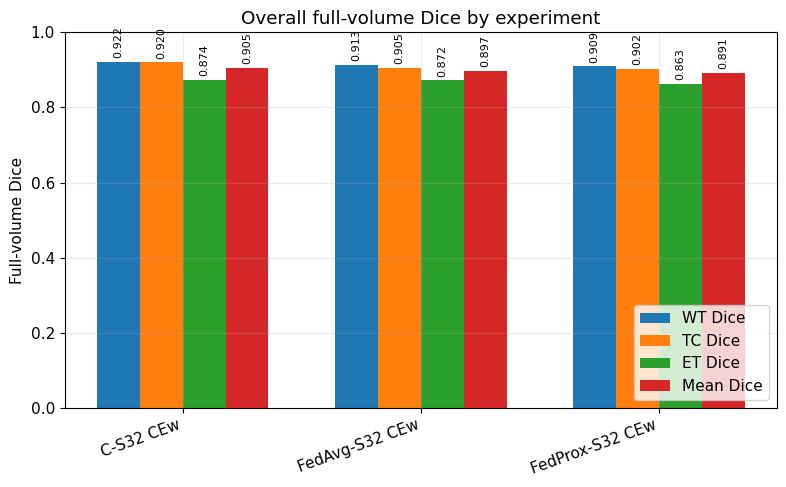

In [23]:
# Figure 1: overall Dice by experiment and region.
plot_df = overall_paper_rounded.copy()
plot_df = plot_df.sort_values("experiment_key")
regions_for_plot = ["WT Dice", "TC Dice", "ET Dice", "Mean Dice"]
regions_for_plot = [c for c in regions_for_plot if c in plot_df.columns]

x = np.arange(len(plot_df))
width = 0.18

fig, ax = plt.subplots(figsize=(max(8, len(plot_df) * 1.8), 5))
for i, metric in enumerate(regions_for_plot):
    ax.bar(x + (i - (len(regions_for_plot)-1)/2) * width, plot_df[metric].values, width, label=metric)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["experiment_short_name"].values, rotation=20, ha="right")
ax.set_ylim(0, 1.0)
ax.set_ylabel("Full-volume Dice")
ax.set_title("Overall full-volume Dice by experiment")
ax.legend(loc="lower right")

for i, metric in enumerate(regions_for_plot):
    for j, val in enumerate(plot_df[metric].values):
        ax.text(
            j + (i - (len(regions_for_plot)-1)/2) * width,
            val + 0.01,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

fig.tight_layout()
figure_outputs["01_overall_dice_by_experiment"] = save_figure(fig, "01_overall_dice_by_experiment")
plt.show()

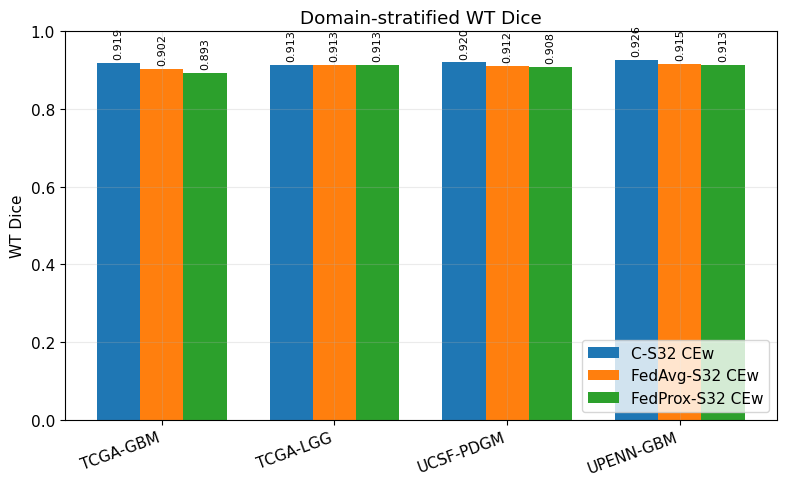

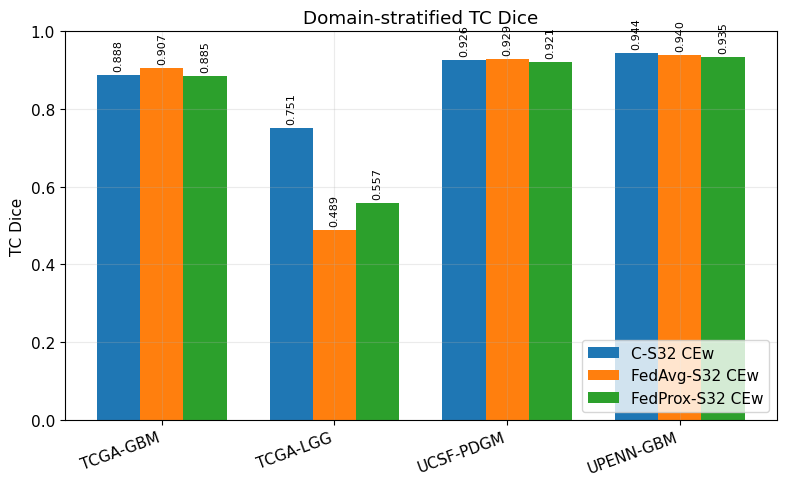

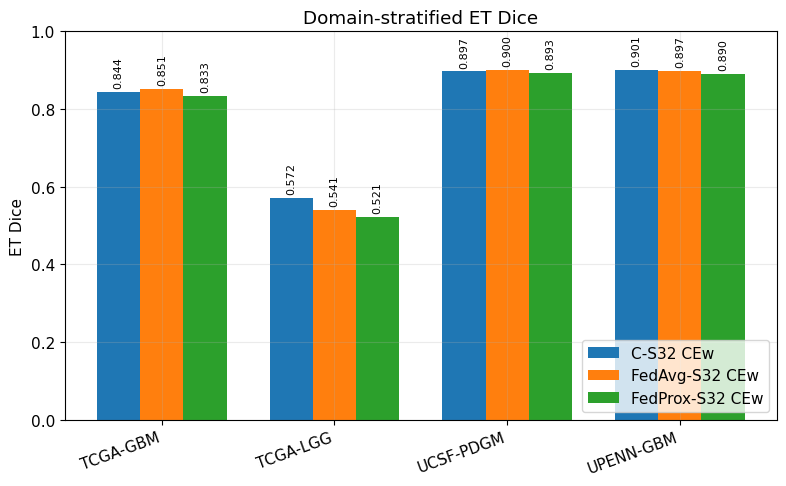

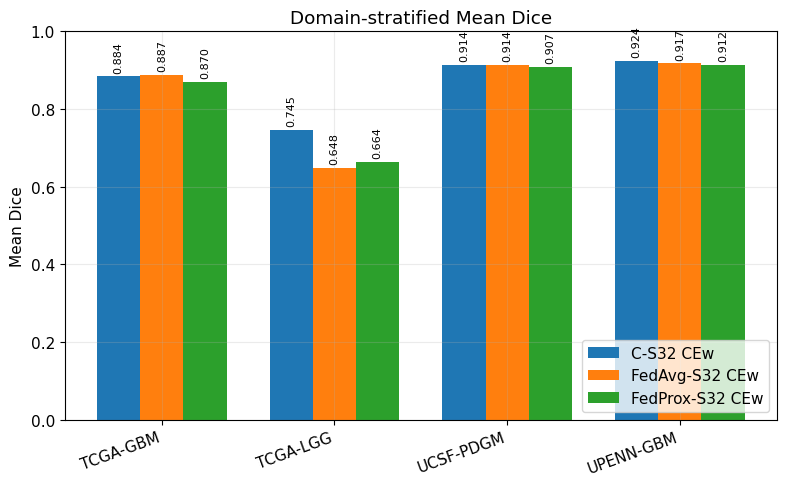

In [24]:
# Figure 2: domain-stratified Dice, one figure per region.
for region_label in ["WT Dice", "TC Dice", "ET Dice", "Mean Dice"]:
    if region_label not in domain_paper_rounded.columns:
        continue

    piv = domain_paper_rounded.pivot(
        index="client_domain",
        columns="experiment_short_name",
        values=region_label
    )
    piv = piv.sort_index()

    fig, ax = plt.subplots(figsize=(max(8, piv.shape[1] * 1.8), 5))
    x = np.arange(len(piv.index))
    n_exp = len(piv.columns)
    width = min(0.8 / max(n_exp, 1), 0.25)

    for i, col in enumerate(piv.columns):
        vals = piv[col].values.astype(float)
        ax.bar(x + (i - (n_exp - 1) / 2) * width, vals, width, label=col)
        for j, val in enumerate(vals):
            if np.isfinite(val):
                ax.text(
                    x[j] + (i - (n_exp - 1) / 2) * width,
                    val + 0.01,
                    f"{val:.3f}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    rotation=90
                )

    ax.set_xticks(x)
    ax.set_xticklabels(piv.index, rotation=20, ha="right")
    ax.set_ylim(0, 1.0)
    ax.set_ylabel(region_label)
    ax.set_title(f"Domain-stratified {region_label}")
    ax.legend(loc="lower right")
    fig.tight_layout()

    safe_name = region_label.lower().replace(" ", "_")
    figure_outputs[f"02_domain_{safe_name}"] = save_figure(fig, f"02_domain_{safe_name}")
    plt.show()

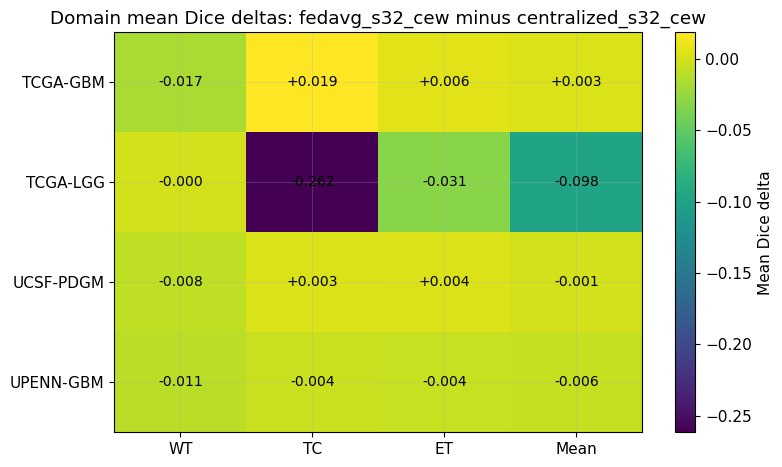

In [25]:
# Figure 3: primary domain delta heatmap.
heat_cols = ["dice_WT_mean_delta", "dice_TC_mean_delta", "dice_ET_mean_delta", "dice_mean_mean_delta"]
heat_df = primary_domain_delta.set_index("client_domain")[heat_cols].copy()
heat_df.columns = ["WT", "TC", "ET", "Mean"]

fig, ax = plt.subplots(figsize=(8, 4.8))
im = ax.imshow(heat_df.values, aspect="auto")
ax.set_xticks(np.arange(len(heat_df.columns)))
ax.set_xticklabels(heat_df.columns)
ax.set_yticks(np.arange(len(heat_df.index)))
ax.set_yticklabels(heat_df.index)
ax.set_title(f"Domain mean Dice deltas: {primary_cur} minus {primary_ref}")

for i in range(heat_df.shape[0]):
    for j in range(heat_df.shape[1]):
        val = heat_df.values[i, j]
        ax.text(j, i, f"{val:+.3f}", ha="center", va="center", fontsize=10)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Mean Dice delta")
fig.tight_layout()
figure_outputs["03_primary_domain_delta_heatmap"] = save_figure(fig, "03_primary_domain_delta_heatmap")
plt.show()

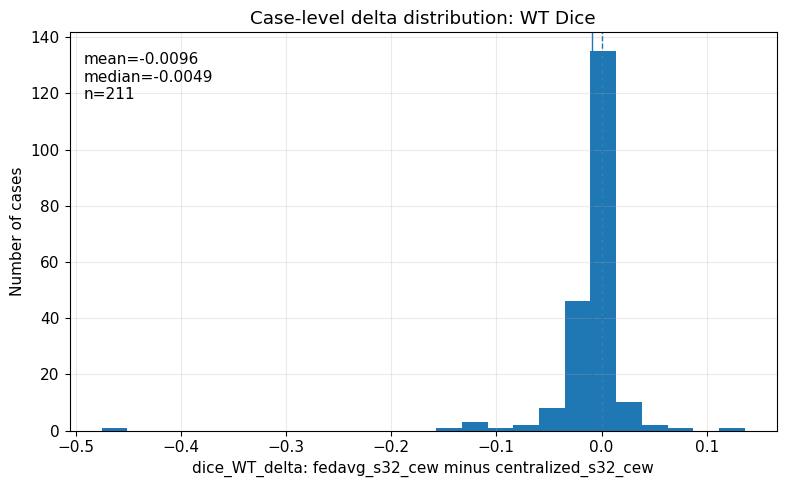

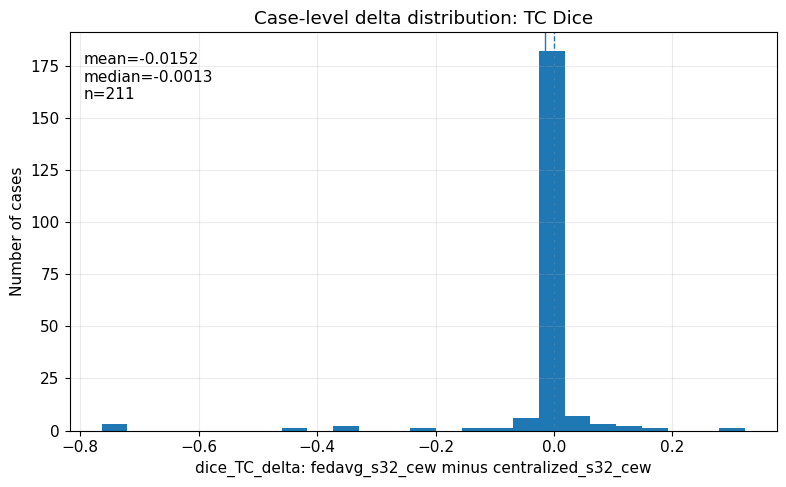

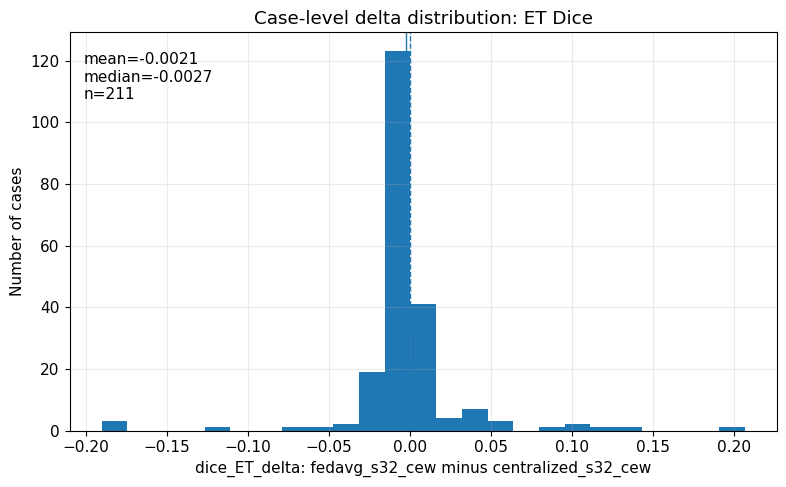

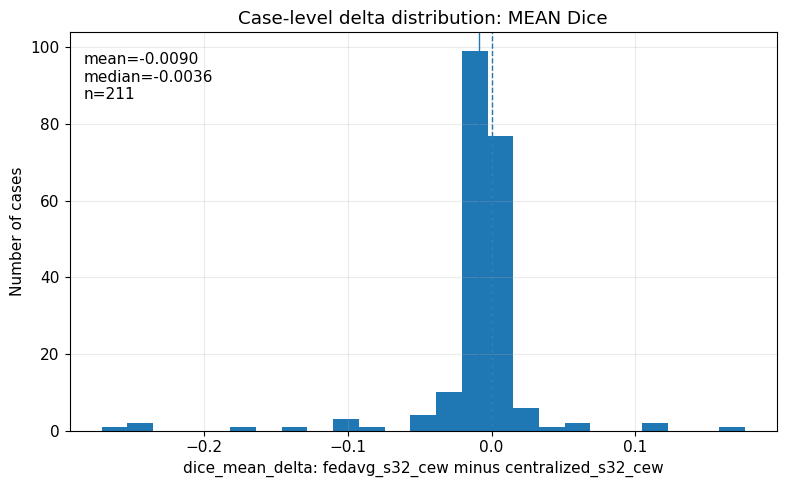

In [26]:
# Figure 4: case-level delta distributions for primary comparison.
for region in ["WT", "TC", "ET", "mean"]:
    delta_col = f"dice_{region}_delta" if region != "mean" else "dice_mean_delta"
    if delta_col not in primary_cmp.columns:
        continue

    x = primary_cmp[delta_col].dropna().astype(float)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(x, bins=25)
    ax.axvline(0.0, linestyle="--", linewidth=1)
    ax.axvline(x.mean(), linestyle="-", linewidth=1)
    ax.set_xlabel(f"{delta_col}: {primary_cur} minus {primary_ref}")
    ax.set_ylabel("Number of cases")
    ax.set_title(f"Case-level delta distribution: {region.upper()} Dice")
    ax.text(
        0.02,
        0.95,
        f"mean={x.mean():+.4f}\nmedian={x.median():+.4f}\nn={len(x)}",
        transform=ax.transAxes,
        va="top"
    )
    fig.tight_layout()

    figure_outputs[f"04_case_delta_distribution_{region}"] = save_figure(
        fig,
        f"04_case_delta_distribution_{region}"
    )
    plt.show()

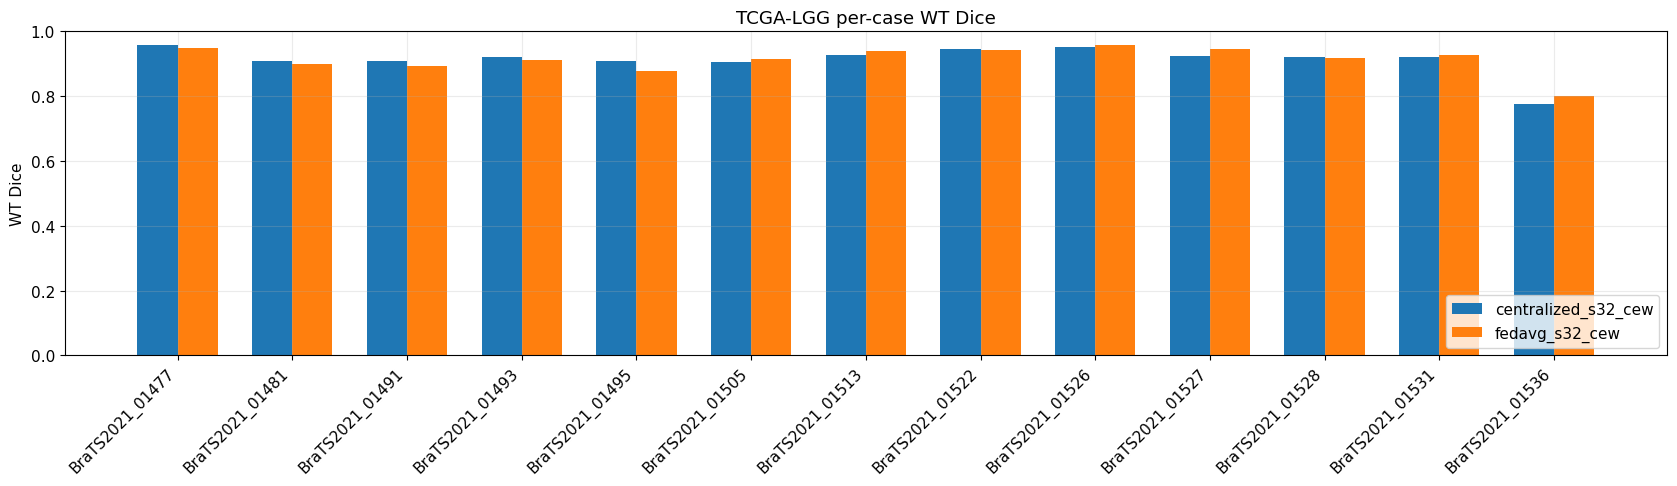

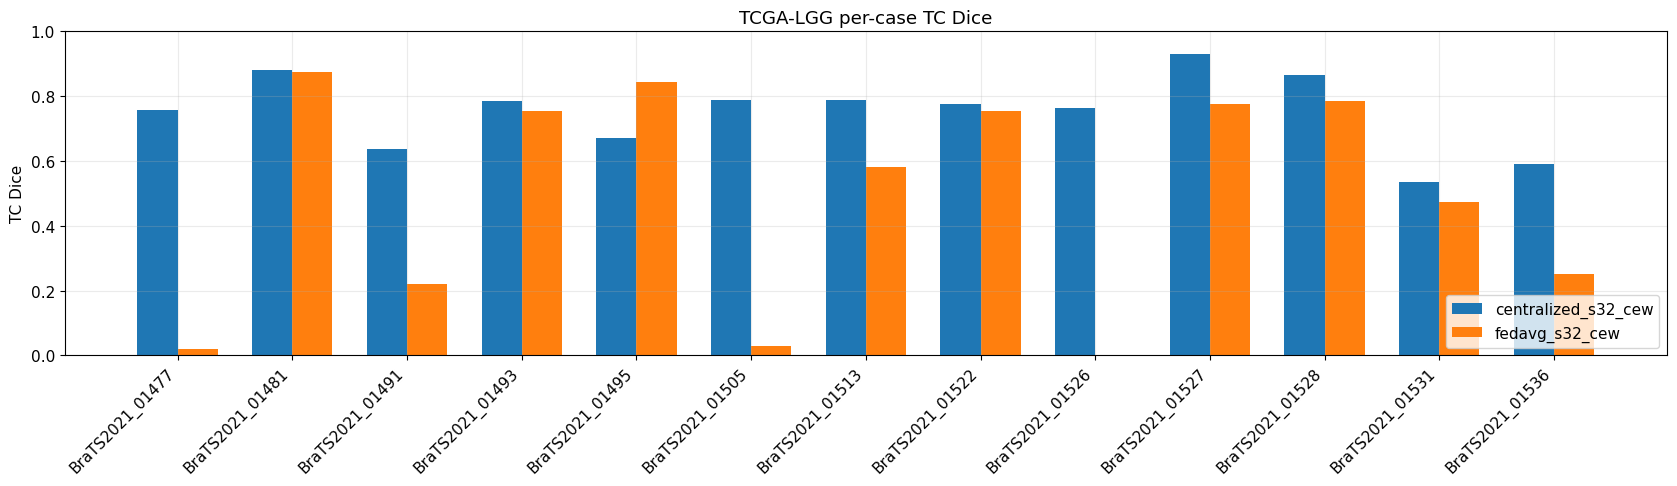

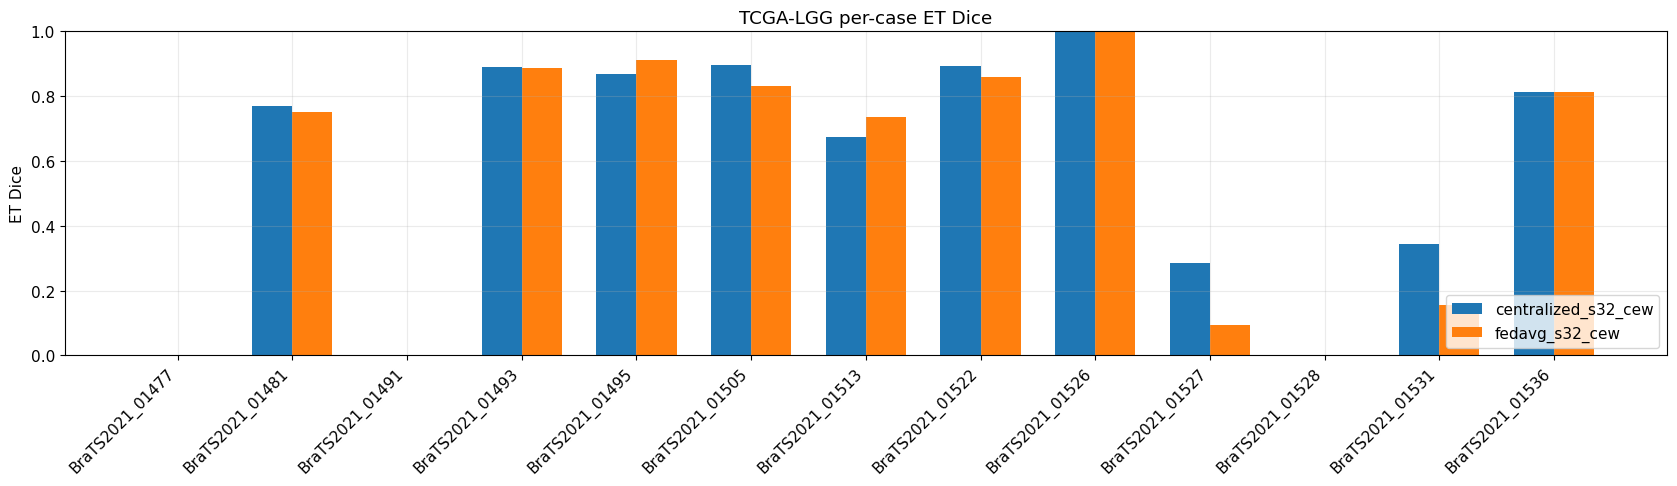

In [27]:
# Figure 5: TCGA-LGG case-level comparison.
if not tcga_lgg_deep_dive.empty:
    for region in ["WT", "TC", "ET"]:
        ref_col = f"dice_{region}_{primary_ref}"
        cur_col = f"dice_{region}_{primary_cur}"
        if ref_col not in tcga_lgg_deep_dive.columns or cur_col not in tcga_lgg_deep_dive.columns:
            continue

        plot_df = tcga_lgg_deep_dive.sort_values("patient_id")
        x = np.arange(len(plot_df))
        width = 0.35

        fig, ax = plt.subplots(figsize=(max(8, len(plot_df) * 1.3), 5))
        ax.bar(x - width/2, plot_df[ref_col].values, width, label=primary_ref)
        ax.bar(x + width/2, plot_df[cur_col].values, width, label=primary_cur)
        ax.set_xticks(x)
        ax.set_xticklabels(plot_df["patient_id"].values, rotation=45, ha="right")
        ax.set_ylim(0, 1.0)
        ax.set_ylabel(f"{region} Dice")
        ax.set_title(f"TCGA-LGG per-case {region} Dice")
        ax.legend(loc="lower right")
        fig.tight_layout()

        figure_outputs[f"05_tcga_lgg_case_{region}"] = save_figure(fig, f"05_tcga_lgg_case_{region}")
        plt.show()
else:
    print("TCGA-LGG deep dive table is empty; skipping TCGA-LGG plots.")

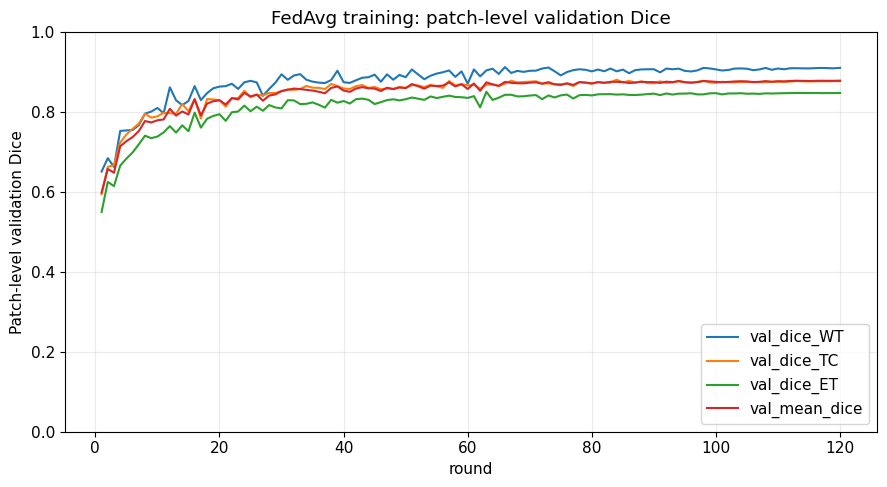

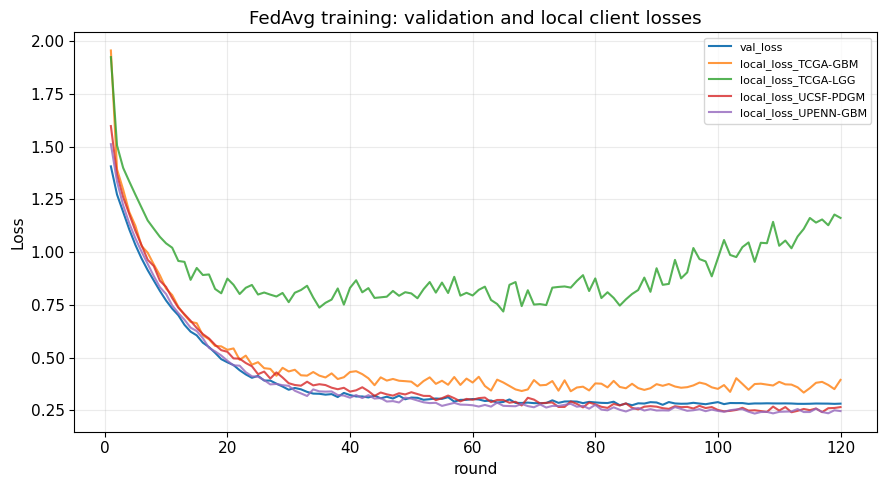

In [28]:
# Figure 6: FedAvg training curves if available.
if "fedavg_s32_cew" in histories:
    hist = histories["fedavg_s32_cew"].copy()
    step_col = "round" if "round" in hist.columns else ("global_round" if "global_round" in hist.columns else None)
    if step_col is None:
        hist["step"] = np.arange(1, len(hist) + 1)
        step_col = "step"

    # Validation Dice curves.
    dice_cols = [c for c in [
        "val_dice_WT",
        "val_dice_TC",
        "val_dice_ET",
        "val_mean_dice"
    ] if c in hist.columns]
    if dice_cols:
        fig, ax = plt.subplots(figsize=(9, 5))
        for col in dice_cols:
            ax.plot(hist[step_col], hist[col], label=col)
        ax.set_xlabel(step_col)
        ax.set_ylabel("Patch-level validation Dice")
        ax.set_ylim(0, 1.0)
        ax.set_title("FedAvg training: patch-level validation Dice")
        ax.legend(loc="lower right")
        fig.tight_layout()
        figure_outputs["06_fedavg_validation_dice_curves"] = save_figure(
            fig,
            "06_fedavg_validation_dice_curves"
        )
        plt.show()

    # Loss curves.
    loss_cols = [c for c in ["val_loss", "train_loss"] if c in hist.columns]
    client_loss_cols = [c for c in hist.columns if c.startswith("local_loss_")]
    if loss_cols or client_loss_cols:
        fig, ax = plt.subplots(figsize=(9, 5))
        for col in loss_cols:
            ax.plot(hist[step_col], hist[col], label=col)
        for col in client_loss_cols:
            ax.plot(hist[step_col], hist[col], label=col, alpha=0.8)
        ax.set_xlabel(step_col)
        ax.set_ylabel("Loss")
        ax.set_title("FedAvg training: validation and local client losses")
        ax.legend(loc="upper right", fontsize=8)
        fig.tight_layout()
        figure_outputs["07_fedavg_loss_curves"] = save_figure(fig, "07_fedavg_loss_curves")
        plt.show()
else:
    print("FedAvg history not loaded; skipping FedAvg training plots.")

## Experiment report

In [33]:


report_parts = [
    "# 06 Experiment Comparison Report",
    "",
    f"Generated: {datetime.now().isoformat(timespec='seconds')}",
    f"Project root: `{PROJECT_ROOT}`",
    "",
    "## Experiments",
    "",
]

for _, row in registry_df.iterrows():
    if not bool(row["enabled"]):
        continue

    status = (
        "loaded"
        if row["key"] in metrics_by_key
        else "missing"
    )

    report_parts.append(
        f"- **{row['name']}** (`{row['key']}`): {status}"
    )
    report_parts.append(
        f"  - metrics: `{row['metrics_path_abs']}`"
    )

    history_path = row.get("history_path_abs")

    if pd.notna(history_path) and history_path:
        report_parts.append(
            f"  - history: `{history_path}`"
        )


report_parts.extend([
    "",
    "## Overall full-volume Dice",
    "",
    overall_paper_rounded.to_markdown(index=False),
    "",
    "## Domain-stratified Dice",
    "",
    domain_paper_rounded.to_markdown(index=False),
    "",
    "## Pairwise deltas",
    "",
    primary_delta_summary.round(6).to_markdown(index=False),
    "",
    "## Domain deltas",
    "",
    primary_domain_delta.round(6).to_markdown(index=False),
    "",
    "## Failure counts",
    "",
    failure_counts.to_markdown(index=False),
    "",
])


if not tcga_lgg_deep_dive.empty:
    report_parts.extend([
        "## TCGA-LGG analysis",
        "",
        tcga_lgg_deep_dive.round(4).to_markdown(index=False),
        "",
    ])


table_files = sorted(TABLE_DIR.glob("*.csv"))
figure_files = sorted(FIG_DIR.glob("*.png"))


report_parts.extend([
    "## Generated outputs",
    "",
    "### Tables",
    "",
    *[f"- `{p}`" for p in table_files],
    "",
    "### Figures",
    "",
    *[f"- `{p}`" for p in figure_files],
    "",
])


report_text = "\n".join(report_parts)

report_path = (
    REPORT_DIR
    / "06_experiment_comparison_report.md"
)

report_path.write_text(
    report_text,
    encoding="utf-8",
)

print("saved report:", report_path)


preview = (
    report_text[:4000] + "\n\n..."
    if len(report_text) > 4000
    else report_text
)

display(Markdown(preview))

saved report: /home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/reports/06_experiment_comparison_report.md


# 06 Experiment Comparison Report

Generated: 2026-09-15T03:36:37
Project root: `/home/mandrakedrink/projects/research_ts_bs`

## Experiments

- **Centralized SegResNet32 final CE-weighted — TEST** (`centralized_s32_cew`): loaded
  - metrics: `/home/mandrakedrink/projects/research_ts_bs/models/centralized_segresnet32_final/full_volume_inference_test/full_volume_test_metrics.csv`
  - history: `/home/mandrakedrink/projects/research_ts_bs/models/centralized_segresnet32_final/segresnet_final_history.csv`
- **FedAvg SegResNet32 final CE-weighted — TEST** (`fedavg_s32_cew`): loaded
  - metrics: `/home/mandrakedrink/projects/research_ts_bs/models/federated_fedavg_segresnet32_final/full_volume_inference_test/full_volume_test_metrics.csv`
  - history: `/home/mandrakedrink/projects/research_ts_bs/models/federated_fedavg_segresnet32_final/fedavg_history.csv`
- **FedProx SegResNet32 final CE-weighted — TEST** (`fedprox_s32_cew`): loaded
  - metrics: `/home/mandrakedrink/projects/research_ts_bs/models/federated_fedprox_segresnet32_final/full_volume_inference_test/full_volume_test_metrics.csv`

## Overall full-volume Dice

| experiment_key      | experiment_name                                  | experiment_short_name   | experiment_family   | experiment_stage    |   WT Dice |   TC Dice |   ET Dice |   Mean Dice |
|:--------------------|:-------------------------------------------------|:------------------------|:--------------------|:--------------------|----------:|----------:|----------:|------------:|
| centralized_s32_cew | Centralized SegResNet32 final CE-weighted — TEST | C-S32 CEw               | centralized         | final_backbone_test |    0.9223 |    0.9202 |    0.874  |      0.9055 |
| fedavg_s32_cew      | FedAvg SegResNet32 final CE-weighted — TEST      | FedAvg-S32 CEw          | federated           | final_fedavg_test   |    0.9127 |    0.9051 |    0.8719 |      0.8966 |
| fedprox_s32_cew     | FedProx SegResNet32 final CE-weighted — TEST     | FedProx-S32 CEw         | federated           | final_fedprox_test  |    0.9091 |    0.902  |    0.8628 |      0.8913 |

## Domain-stratified Dice

| experiment_key      | experiment_name                                  | experiment_short_name   | client_domain   |   n |   WT Dice |   TC Dice |   ET Dice |   Mean Dice |
|:--------------------|:-------------------------------------------------|:------------------------|:----------------|----:|----------:|----------:|----------:|------------:|
| centralized_s32_cew | Centralized SegResNet32 final CE-weighted — TEST | C-S32 CEw               | TCGA-GBM        |  20 |    0.9189 |    0.888  |    0.8444 |      0.8838 |
| centralized_s32_cew | Centralized SegResNet32 final CE-weighted — TEST | C-S32 CEw               | TCGA-LGG        |  13 |    0.9132 |    0.7511 |    0.5719 |      0.7454 |
| centralized_s32_cew | Centralized SegResNet32 final CE-weighted — TEST | C-S32 CEw               | UCSF-PDGM       |  76 |    0.9199 |    0.9265 |    0.8967 |      0.9144 |
| centralized_s32_cew | Centralized SegResNet32 final CE-weighted — TEST | C-S32 CEw               | UPENN-GBM       | 102 |    0.9259 |    0.9435 |    0.9014 |      0.9236 |
| fedavg_s32_cew      | FedAvg SegResNet32 final CE-weighted — TEST      | FedAvg-S32 CEw          | TCGA-GBM        |  20 |    0.9024 |    0.9067 |    0.8508 |      0.8866 |
| fedavg_s32_cew      | FedAvg SegResNet32 final CE-weighted — TEST      | FedAvg-S32 CEw          | TCGA-LGG        |  13 |    0.9131 |    0.4894 |    0.5412 |      0.6479 |
| fedavg_s32_cew      | FedAvg SegResNet32 final CE-weighted — TEST      | FedAvg-S32 CEw          | UCSF-PDGM       |  76 |    0.9118 |    0.9292 |    0.9005 |      0.9138 |
| fedavg_s32_cew      | FedAvg SegResNet32 final CE-weighted — TEST      | FedAvg-S32 CEw          | UPENN-GBM       | 102 |    0.9154 |    0.9397 |    0.8969 |      0.9174 |
| fedprox_s32_cew     | FedProx SegResNet32 final CE-weighted — TEST     | FedProx-S32 CEw         | TCGA-GBM        |  

...

## Run manifest

In [37]:
run_manifest = {
    "generated_at": datetime.now().isoformat(timespec="seconds"),
    "project_root": str(PROJECT_ROOT),
    "output_root": str(OUTPUT_ROOT),
    "table_dir": str(TABLE_DIR),
    "figure_dir": str(FIG_DIR),
    "report_dir": str(REPORT_DIR),
    "cfg": CFG,
    "loaded_experiment_keys": list(metrics_by_key.keys()),
    "primary_reference_key": primary_ref,
    "primary_current_key": primary_cur,
    "n_all_metric_rows": int(len(all_metrics)),
    "integrity_checks": integrity_df.to_dict(orient="records"),
    "patient_set_alignment": alignment_df.to_dict(orient="records"),
    "figure_outputs": figure_outputs,
    "tables_csv": [str(p) for p in sorted(TABLE_DIR.glob("*.csv"))],
    "reports": [str(p) for p in sorted(REPORT_DIR.glob("*.md"))],
}

manifest_out_path = LOG_DIR / "06_run_manifest.json"
with open(manifest_out_path, "w", encoding="utf-8") as f:
    json.dump(run_manifest, f, indent=2, ensure_ascii=False, default=str)

print("saved run manifest:", manifest_out_path)

saved run manifest: /home/mandrakedrink/projects/research_ts_bs/docs/06_experiment_comparison_test/logs/06_run_manifest.json


## Output validation

In [35]:


checks = {
    "centralized_loaded": (
        "centralized_s32_cew" in metrics_by_key
    ),
    "fedavg_loaded": (
        "fedavg_s32_cew" in metrics_by_key
    ),
    "fedprox_loaded": (
        "fedprox_s32_cew" in metrics_by_key
    ),
    "primary_pairwise_available": (
        primary_ref in metrics_by_key
        and primary_cur in metrics_by_key
    ),
    "patient_sets_aligned": bool(
        (alignment_df["n_missing_from_experiment"] == 0).all()
        and (alignment_df["n_extra_in_experiment"] == 0).all()
    ),
    "integrity_passed": bool(
        integrity_df["all_rows_are_expected_split"].all()
        and (integrity_df["n_duplicate_rows"] == 0).all()
        and (integrity_df["dice_min"] >= -1e-8).all()
        and (integrity_df["dice_max"] <= 1 + 1e-8).all()
        and (integrity_df["min_volume_or_error"] >= 0).all()
    ),
}

checks["complete"] = all(checks.values())


checks_df = pd.DataFrame([checks])

safe_display(
    "Segmentation comparison checks",
    checks_df,
)

save_dataframe(
    checks_df,
    "27_output_checks",
)


if checks["complete"]:
    display(
        Markdown(
            "**PASS:** segmentation comparison outputs are complete "
            "and patient alignment and integrity checks passed."
        )
    )
else:
    failed = [
        name
        for name, passed in checks.items()
        if name != "complete" and not passed
    ]

    display(
        Markdown(
            "**FAIL:** missing or invalid checks: "
            + ", ".join(f"`{name}`" for name in failed)
        )
    )

### Segmentation comparison checks

,centralized_loaded,fedavg_loaded,fedprox_loaded,primary_pairwise_available,patient_sets_aligned,integrity_passed,complete
0,True,True,True,True,True,True,True


**PASS:** segmentation comparison outputs are complete and patient alignment and integrity checks passed.